# 05 — VAR Baseline

## Objetivo

Estimar o modelo VAR de referência (baseline) para análise dos efeitos da 
política monetária sobre PIB (proxy: IBC-Br) e inflação (IPCA) no Brasil, 
no período 2003-2025 em frequência mensal.

Este é o coração do projeto. Os resultados deste notebook serão comparados 
com:

- A monografia original (modelo VAR trimestral 2002-2024)
- O BVAR com Minnesota prior (notebook 06)
- O VAR com sign restrictions (notebook 07)

## Decisões herdadas dos blocos anteriores

| Item | Decisão | Origem |
|------|---------|--------|
| Janela temporal | 2003-01 a 2025-12 (276 obs mensais) | Bloco 3 |
| Tratamento da pandemia | Dummies para mar-set 2020 | Bloco 3 |
| Especificação | VAR em diferenças (não VECM) | Bloco 4 |
| Ordem de integração das séries | 8 séries I(1), IPCA I(0) | Bloco 4 |
| Dummies de quebra estrutural | Selic 2017, cambio/indústria 2014, crédito 2015 | Bloco 4 |

## Análises de robustez planejadas

Conforme o princípio de parcimônia adotado, as seguintes especificações 
alternativas ficam registradas para avaliação futura:

| # | Alternativa | Origem |
|---|-------------|--------|
| R1 | Modelo incluindo crédito total (canal de crédito) | Definição de variáveis |
| R2 | Produção industrial no lugar do IBC-Br | Definição de variáveis |
| R3 | Janela excluindo 2003-2004 (resíduos da crise pré-Lula) | Bloco 4 |
| R4 | Selic com duas dummies de quebra (2017 + 2021) | Análise visual |
| R5 | VECM para o subsistema de demanda por moeda | Bloco 4 |

## Estrutura do notebook

1. Construção das variáveis finais (diferenças)
2. Construção das dummies de quebra estrutural
3. Definição do conjunto de variáveis
4. Ordenação de Cholesky
5. Seleção de defasagens
6. Estimação e diagnósticos
7. IRFs e decomposição da variância
8. Comparação com a monografia

## 1. Construção das variáveis finais

### Decisão de modelagem

Conjunto final de 6 variáveis para o VAR baseline:

| Variável | Transformação | Papel no modelo |
|----------|--------------|-----------------|
| `ln_commodities` | Primeira diferença | Controle exógeno externo |
| `ln_ibcbr` | Primeira diferença | Atividade econômica |
| `ipca` | Nível | Inflação realizada (I(0)) |
| `exp_ipca_12m` | Primeira diferença | Expectativa forward-looking |
| `selic` | Primeira diferença | Instrumento de política monetária |
| `ln_cambio` | Primeira diferença | Variável cambial |

**Diferenças vs nível:** todas as séries I(1) entram em primeira diferença 
(ver Bloco 4 para fundamentação). O IPCA, classificado como I(0), entra 
em nível.

**Interpretação econômica das diferenças do log:** $\Delta \ln(y_t) = 
\ln(y_t) - \ln(y_{t-1}) \approx$ taxa de crescimento mensal de $y_t$ 
(para valores pequenos). Assim, "$\Delta$ ln_ibcbr" representa 
aproximadamente a taxa de crescimento mensal do indicador de atividade.

### Variáveis fora do baseline (análises de robustez futuras)

- `ln_prod_industrial`: redundante com IBC-Br
- `ln_credito_total`: canal de crédito específico (modelo de robustez)
- `ln_m1`: endógeno sob regime de metas com taxa de juros como instrumento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')

# Carrega o dataset tratado do Bloco 3
df = pd.read_csv(
    DATA_PROCESSED / 'series_tratadas.csv',
    index_col=0,
    parse_dates=True
)

print(f"Dataset carregado: {df.shape}")
print(f"Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")

Dataset carregado: (276, 16)
Período: 2003-01 a 2025-12


In [2]:
# Construção das variáveis finais do modelo

# Séries que entram em primeira diferença (todas as I(1))
series_diff = [
    'ln_commodities',
    'ln_ibcbr',
    'exp_ipca_12m',
    'selic',
    'ln_cambio',
]

# Séries que entram em nível (I(0))
series_nivel = [
    'ipca',
]

# Constrói o DataFrame do modelo
df_modelo = pd.DataFrame(index=df.index)

# Primeiras diferenças (prefixo "d_" para deixar claro)
for col in series_diff:
    df_modelo[f'd_{col}'] = df[col].diff()

# Séries em nível mantêm o nome original
for col in series_nivel:
    df_modelo[col] = df[col]

# Adiciona as dummies de pandemia (que já existem no df)
dummies_pandemia = [c for c in df.columns if c.startswith('dummy_covid_')]
for col in dummies_pandemia:
    df_modelo[col] = df[col]

print(f"\nDataFrame do modelo:")
print(f"Shape: {df_modelo.shape}")
print(f"\nColunas:")
for c in df_modelo.columns:
    print(f"  - {c}")


DataFrame do modelo:
Shape: (276, 13)

Colunas:
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio
  - ipca
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09


In [3]:
# Verificação da Etapa 5.1
print("=" * 70)
print("VERIFICAÇÃO DO df_modelo")
print("=" * 70)

print(f"\nShape: {df_modelo.shape}")
print(f"\nPeríodo: {df_modelo.index.min().strftime('%Y-%m')} a {df_modelo.index.max().strftime('%Y-%m')}")

# Variáveis em diferença
vars_diff = [c for c in df_modelo.columns if c.startswith('d_')]
print(f"\nVariáveis em diferença ({len(vars_diff)}):")
for v in vars_diff:
    print(f"  - {v}")

# Variáveis em nível
vars_nivel = [c for c in df_modelo.columns if c == 'ipca']
print(f"\nVariáveis em nível ({len(vars_nivel)}):")
for v in vars_nivel:
    print(f"  - {v}")

# Dummies de pandemia
dummies = [c for c in df_modelo.columns if c.startswith('dummy_covid_')]
print(f"\nDummies de pandemia ({len(dummies)}):")
for d in dummies:
    print(f"  - {d}")

print(f"\nNaNs por coluna (esperado: 1 NaN em cada série diferenciada, na primeira linha):")
print(df_modelo.isna().sum())

print(f"\nPrimeiras 3 linhas:")
print(df_modelo.head(3))

VERIFICAÇÃO DO df_modelo

Shape: (276, 13)

Período: 2003-01 a 2025-12

Variáveis em diferença (5):
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio

Variáveis em nível (1):
  - ipca

Dummies de pandemia (7):
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09

NaNs por coluna (esperado: 1 NaN em cada série diferenciada, na primeira linha):
d_ln_commodities       1
d_ln_ibcbr             1
d_exp_ipca_12m         1
d_selic                1
d_ln_cambio            1
ipca                   0
dummy_covid_2020_03    0
dummy_covid_2020_04    0
dummy_covid_2020_05    0
dummy_covid_2020_06    0
dummy_covid_2020_07    0
dummy_covid_2020_08    0
dummy_covid_2020_09    0
dtype: int64

Primeiras 3 linhas:
            d_ln_commodities  d_ln_ibcbr  d_exp_ipca_12m  d_selic  \
Date                                                                
2003-01-01

## 2. Visualização das variáveis do modelo

Antes de construir dummies de quebra estrutural, visualizamos as séries no 
formato que entrarão no modelo VAR. Este passo é importante porque:

1. **Confirmação visual da estacionariedade:** as séries em diferença devem 
   oscilar em torno de média estável (idealmente próxima de zero ou um valor 
   constante), sem tendência aparente.

2. **Identificação de mudanças de drift:** se a média da diferença muda em 
   algum ponto da série, isso é evidência de **mudança de regime** que 
   deve ser modelada via dummy de degrau (não de pulso).

3. **Identificação de outliers pontuais:** se há valores extremos isolados 
   (além do trauma da pandemia já tratado), podem indicar pontos que 
   precisam de tratamento adicional.

4. **Decisão sobre tipo de dummy de quebra:**
   - Se a mudança é **gradual ao longo de meses** → dummy de degrau
   - Se a mudança é **um único choque pontual** → dummy de pulso

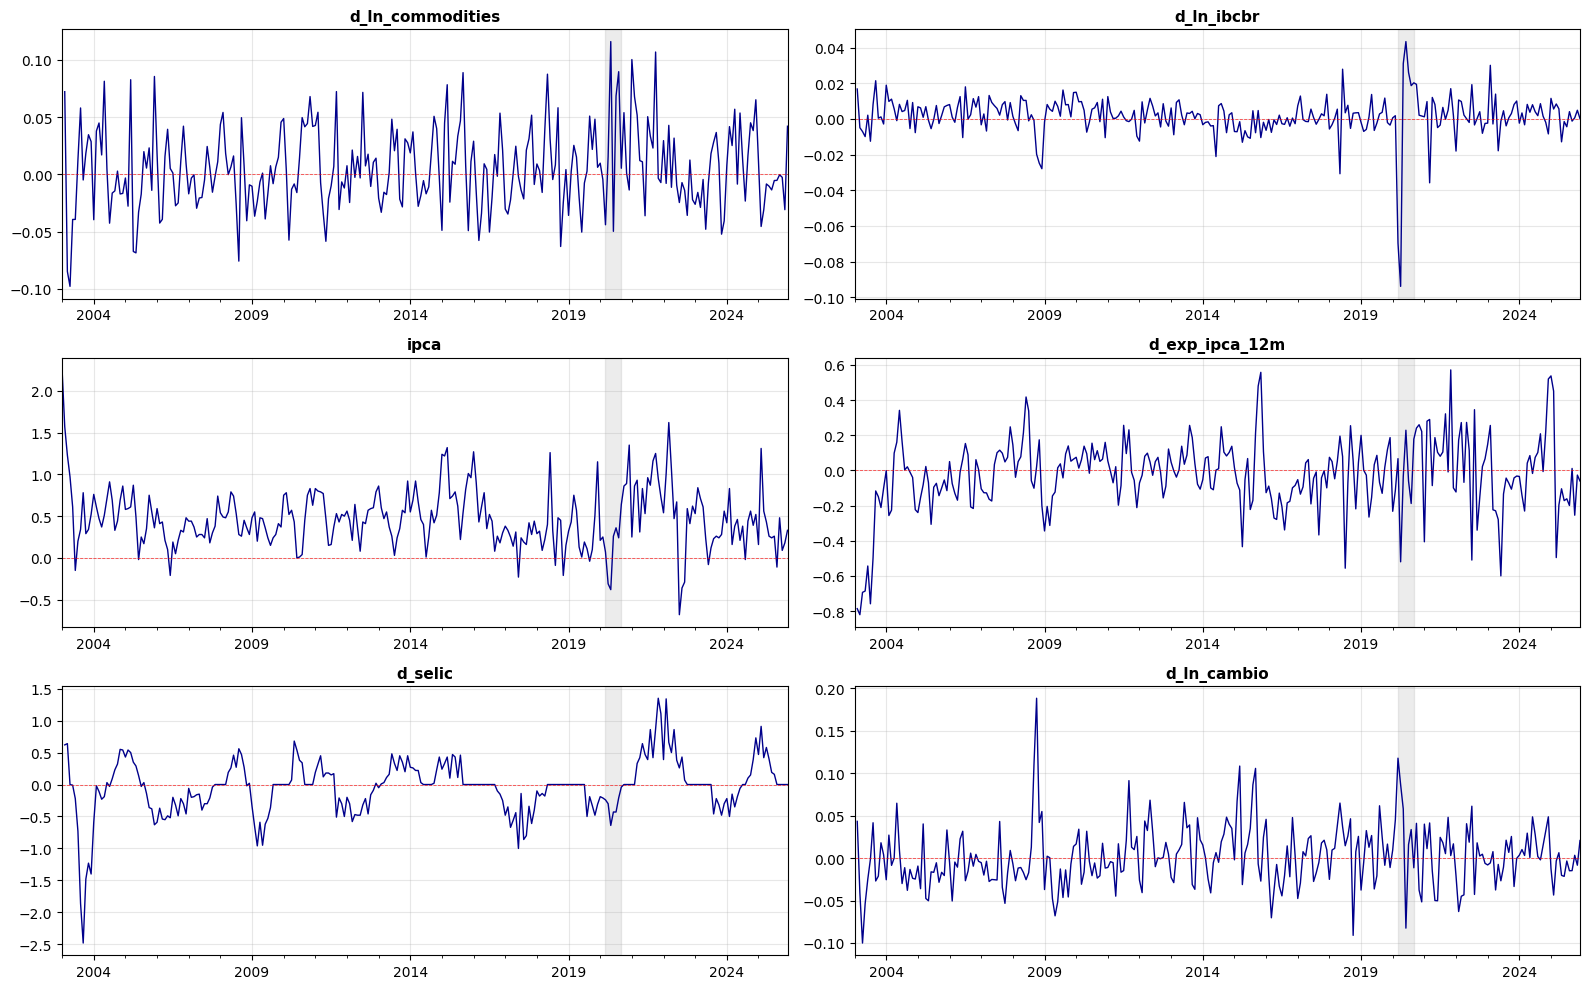

In [4]:
# Variáveis do modelo (em diferença ou nível)
vars_modelo = [
    'd_ln_commodities',
    'd_ln_ibcbr',
    'ipca',  # única em nível
    'd_exp_ipca_12m',
    'd_selic',
    'd_ln_cambio',
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_modelo):
    ax = axes[i]
    df_modelo[col].plot(ax=ax, color='darkblue', linewidth=1)
    
    # Linha horizontal em zero como referência
    ax.axhline(y=0, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    
    # Sombreia o período da pandemia para referência
    ax.axvspan('2020-03', '2020-09', alpha=0.15, color='gray')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_variaveis_modelo.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.1 Análise visual das variáveis do modelo

Inspeção das 6 séries no formato em que entrarão no VAR (cinco em primeira 
diferença, IPCA em nível). A faixa cinza marca o período da pandemia 
(mar-set 2020), já tratado por dummies.

#### d_ln_commodities

Oscila em torno de zero ao longo de todo o período, confirmando 
estacionariedade. Observa-se **aumento da volatilidade a partir de 2019-2020**, 
sustentado até 2025 — efeito combinado do fim do superciclo de commodities, 
choques pós-pandemia e guerra na Ucrânia. A maior variância no período recente 
é parte legítima da dinâmica e não demanda tratamento adicional, mas deve ser 
considerada na interpretação dos resultados.

#### d_ln_ibcbr

Oscila em torno de zero, com o **outlier brutal da pandemia** claramente 
visível (queda de ~9% em abril/2020, recuperação nos meses seguintes). Sem o 
tratamento via dummies de pandemia, esse ponto dominaria a estimação. Fora 
da pandemia, o comportamento é estacionário e bem-comportado.

#### ipca

Única série em nível. Estacionária em torno de média positiva (~0,5% ao mês), 
com **outlier no início da amostra** (janeiro/2003, ~2%), resíduo da crise de 
credibilidade pré-Lula. Como o IPCA entra em nível, esse ponto permanece nos 
dados. Decisão: **aceitar o outlier no baseline** (apenas 1 observação em 276); 
o efeito será avaliado na análise de robustez que exclui 2003-2004 (R3).

#### d_exp_ipca_12m

Comportamento estacionário com **drift levemente positivo a partir de 2020-2021**: 
sucessão de picos positivos persistentes (2021, 2022, 2024) reflete a 
**desancoragem parcial das expectativas** pós-pandemia. Decisão: **não incluir 
dummy de quebra** para esta série — a desancoragem é fenômeno econômico 
relevante que o modelo deve capturar endogenamente, especialmente o feedback 
entre expectativa e Selic.

#### d_selic

A série revela **três regimes distintos**:

1. **2003-2017**: oscilação em torno de zero (stop-and-go monetário do período)
2. **2017-2020**: média negativa (ciclo de cortes, Selic atingindo mínimos 
   históricos de ~2% a.a.)
3. **2021-2025**: ciclo de aperto-afrouxamento-aperto dentro do regime 
   pós-pandemia, com média próxima de zero mas alta volatilidade

Há ainda um **outlier expressivo em 2003** (resolução da incerteza sobre a 
posse de Lula). A transição mais estrutural é a de 2017 (entrada no regime de 
juros baixos). Decisão: **uma dummy de quebra em 2017-01** no baseline; a 
possível segunda quebra (~2021) fica registrada como robustez (R4).

#### d_ln_cambio

Sem mudança brusca de média, mas há **alteração sutil de regime**: até ~2012-2013 
predominam valores negativos (apreciação do real); a partir de 2013-2014 os 
valores positivos tornam-se mais frequentes (depreciação estrutural). Dois 
**outliers** destacam-se: a crise financeira global (2008-2009) e a pandemia 
(2020). A mudança de regime, ainda que sutil, é consistente com a análise do 
Bloco 3. Decisão: **dummy de quebra de degrau em 2014-09**.

### 2.2 Síntese das decisões

| Variável | Tratamento de quebra | Justificativa |
|----------|---------------------|---------------|
| `d_selic` | Dummy de degrau em 2017-01 | Entrada no regime de juros baixos |
| `d_ln_cambio` | Dummy de degrau em 2014-09 | Mudança de regime cambial |
| `d_exp_ipca_12m` | Nenhuma | Desancoragem é dinâmica endógena relevante |
| `ipca` | Nenhuma | Outlier de 2003 aceito; avaliado em robustez (R3) |
| `d_ln_commodities` | Nenhuma | Maior variância pós-2020 é parte da dinâmica |
| `d_ln_ibcbr` | Nenhuma | Pandemia já tratada por dummies dedicadas |

## 3. Quebras estruturais — decisão revisada

### Reavaliação

O Bloco 4 identificou quebras estruturais no **nível** de `selic` e 
`ln_cambio` (mudança de patamar). A intenção inicial era incluir dummies 
de degrau para capturar essas quebras.

A inspeção visual das séries em diferença (Etapa 2) revelou que essa 
abordagem é **conceitualmente inadequada**:

- A quebra estrutural ocorria no **nível** das séries (mudança permanente 
  de patamar).
- O modelo VAR é especificado em **primeira diferença**.
- A operação de diferenciação **absorve mudanças de patamar**: uma quebra 
  de nível se manifesta na série diferenciada como poucos pontos atípicos 
  no período de transição, não como mudança de regime permanente.
- Dummies de degrau capturam mudança de *drift* (média da série 
  diferenciada). Como `d_selic` e `d_ln_cambio` oscilam em torno de média 
  aproximadamente constante (≈ 0) em todo o período, não há *drift* a 
  capturar.

### Decisão

**Não incluir dummies de quebra estrutural no baseline.** As séries 
diferenciadas absorvem naturalmente as quebras de nível como eventos 
pontuais de transição, que o VAR trata como parte da dinâmica.

### Registro para robustez futura (R4 revisado)

Testar dummies de **pulso** (não degrau) nos meses específicos de transição 
de regime — final de 2016 para a Selic, segundo semestre de 2014 para o 
câmbio — para verificar se a captura desses pontos de transição altera 
materialmente os resultados.

### Princípio metodológico

A correção ilustra a importância da inspeção visual antes da estimação: 
a decisão tomada com base apenas nos testes do Bloco 4 (quebra no nível) 
não se traduziu corretamente para a especificação em diferenças. O erro 
foi detectado visualmente e corrigido.

In [5]:
# Remove as dummies de quebra estrutural (decisão revisada — ver Markdown acima)
colunas_quebra = ['dummy_quebra_selic', 'dummy_quebra_cambio']

for col in colunas_quebra:
    if col in df_modelo.columns:
        df_modelo = df_modelo.drop(columns=col)
        print(f"Removida: {col}")
    else:
        print(f"Não encontrada (já removida ou nunca criada): {col}")

print(f"\nShape atual do df_modelo: {df_modelo.shape}")
print(f"\nColunas atuais:")
for c in df_modelo.columns:
    print(f"  - {c}")

Não encontrada (já removida ou nunca criada): dummy_quebra_selic
Não encontrada (já removida ou nunca criada): dummy_quebra_cambio

Shape atual do df_modelo: (276, 13)

Colunas atuais:
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio
  - ipca
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09


## 4. Conjunto final de variáveis do modelo

Consolidando as decisões dos blocos anteriores e das etapas 1 a 3 deste bloco:

### Variáveis endógenas (6)

Estas são as variáveis cuja dinâmica conjunta o VAR vai modelar — cada uma 
responde a choques nas outras.

| Variável | Forma | Papel econômico |
|----------|-------|-----------------|
| `d_ln_commodities` | 1ª diferença do log | Choque externo (Brasil é tomador de preços) |
| `d_ln_ibcbr` | 1ª diferença do log | Atividade econômica (proxy mensal do PIB) |
| `ipca` | Nível | Inflação realizada |
| `d_exp_ipca_12m` | 1ª diferença | Expectativa de inflação (forward-looking) |
| `d_selic` | 1ª diferença | Instrumento de política monetária |
| `d_ln_cambio` | 1ª diferença do log | Variável cambial |

### Variáveis exógenas (7)

Não respondem a choques do sistema, mas afetam as endógenas.

| Variável | Tipo | Função |
|----------|------|--------|
| `dummy_covid_2020_03` a `dummy_covid_2020_09` | Pulso | Isolar choque agudo da pandemia |

### Sem dummies de quebra estrutural

Conforme correção metodológica da Etapa 3: as quebras estruturais 
identificadas no Bloco 4 ocorrem no nível das séries; a diferenciação 
absorve essas quebras como eventos pontuais, dispensando dummies de degrau.

### Dimensionamento do modelo

Com 6 variáveis endógenas e 7 exógenas, em amostra de 275 observações 
(janeiro/2003 a dezembro/2025, sem o primeiro mês perdido na diferenciação), 
o modelo é razoavelmente dimensionado:

- **VAR(2):** 6 × (6 × 2 + 1 + 7) = 120 coeficientes estimados (20 por equação)
- **VAR(4):** 6 × (6 × 4 + 1 + 7) = 192 coeficientes estimados (32 por equação)
- **VAR(6):** 6 × (6 × 6 + 1 + 7) = 264 coeficientes estimados (44 por equação)

Com VAR(4) temos ~8,6 observações por parâmetro estimado. Confortável. VAR(6) 
já fica apertado.

In [6]:
# Define o conjunto final de variáveis
variaveis_endogenas = [
    'd_ln_commodities',   # 1 — mais exógena
    'd_ln_ibcbr',         # 2
    'ipca',               # 3
    'd_exp_ipca_12m',     # 4
    'd_selic',            # 5
    'd_ln_cambio',        # 6 — mais endógena
]

variaveis_exogenas = [c for c in df_modelo.columns if c.startswith('dummy_covid_')]

# Verificação
print(f"Variáveis endógenas ({len(variaveis_endogenas)}):")
for v in variaveis_endogenas:
    print(f"  - {v}")

print(f"\nVariáveis exógenas ({len(variaveis_exogenas)}):")
for v in variaveis_exogenas:
    print(f"  - {v}")

# Confirma que tudo está no df_modelo
todas_vars = variaveis_endogenas + variaveis_exogenas
faltantes = set(todas_vars) - set(df_modelo.columns)
extras = set(df_modelo.columns) - set(todas_vars)

if faltantes:
    print(f"\n⚠ Faltantes em df_modelo: {faltantes}")
if extras:
    print(f"\n⚠ Extras em df_modelo (não vão ser usados): {extras}")
if not faltantes and not extras:
    print(f"\n✓ df_modelo contém exatamente as variáveis necessárias")

Variáveis endógenas (6):
  - d_ln_commodities
  - d_ln_ibcbr
  - ipca
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio

Variáveis exógenas (7):
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09

✓ df_modelo contém exatamente as variáveis necessárias


## 5. Ordenação de Cholesky

### Decisão

| Posição | Variável | Justificativa |
|:---:|----------|---------------|
| 1 | `d_ln_commodities` | Variável exógena externa: Brasil é tomador de preços internacionais |
| 2 | `d_ln_ibcbr` | Atividade econômica com rigidez quantitativa (ajuste de produção e emprego é lento) |
| 3 | `ipca` | Rigidez nominal novo-keynesiana: preços ajustam contemporaneamente a choques de oferta e demanda, não à política monetária |
| 4 | `d_exp_ipca_12m` | Forward-looking: mercado forma expectativa observando preços, atividade e commodities; antecede decisão do BC |
| 5 | `d_selic` | Instrumento de política: BC reage à expectativa (não ao IPCA realizado) sob regime de metas |
| 6 | `d_ln_cambio` | Variável financeira de alta liquidez: absorve contemporaneamente todas as outras |

### Implicações da ordenação para identificação dos choques

A decomposição de Cholesky impõe estrutura recursiva contemporânea:

- A **posição 1 (commodities)** não responde no mesmo mês a nenhuma outra variável — apenas a choques globais
- O **choque monetário identificado (Selic, posição 5)** é o componente da variação da Selic que **não é explicado** por commodities, IBC-Br, IPCA ou expectativa de inflação contemporâneos. Ou seja, é o componente "surpresa" da decisão do Copom relativa às condições macroeconômicas observadas
- O **câmbio (posição 6)** responde contemporaneamente a todas as outras, refletindo sua natureza de ativo financeiro líquido em frequência mensal

### Diferenças críticas em relação à monografia

| Aspecto | Monografia | Projeto atual |
|---------|-----------|---------------|
| Expectativa de inflação | Ausente do modelo | Posição 4 (antes da Selic) |
| Posição relativa IPCA-Selic | IPCA antes, sem expectativa entre | IPCA → expectativa → Selic |
| Câmbio | Tratado como exógeno | Endógeno (posição 6) |
| Commodities | Tratado como exógeno | Endógena (posição 1) |

A inclusão da expectativa de inflação **entre IPCA e Selic** é a mudança 
metodológica mais importante: ela permite identificar o choque monetário 
"limpo" via Cholesky, abrindo caminho para resolver o *price puzzle* 
identificado na monografia.

### Limitação reconhecida (crítica de Cooley-LeRoy, 1985)

A ordenação de Cholesky depende de hipóteses de identificação econômicas, 
não testadas empiricamente. Diferentes ordenações geram diferentes IRFs. Por 
essa razão:

- A ordenação adotada é defendida com base em mecanismo econômico, não 
  conveniência computacional
- O Bloco 7 implementará **sign restrictions** como abordagem alternativa de 
  identificação, mais robusta a hipóteses recursivas arbitrárias
- A robustez à ordenação será verificada permutando posições limítrofes 
  (ex: trocar posições 4 e 5) em análise de sensibilidade

## 6. Seleção de defasagens

### Por que importa

O número de defasagens $p$ no VAR($p$) controla quanta história das séries 
o modelo "lembra" ao gerar previsões e impulso-respostas. A escolha envolve 
trade-off clássico:

- **$p$ baixo:** modelo parcimonioso, fácil de interpretar, mas pode deixar 
  estrutura dinâmica nos resíduos (autocorrelação residual, violando 
  hipóteses do modelo)
- **$p$ alto:** captura dinâmica completa, mas consome graus de liberdade, 
  estima muitos parâmetros e infla erros-padrão dos coeficientes individuais

A escolha "certa" depende de quanta dinâmica genuína existe nas séries. Em 
macro mensal brasileira, valores típicos são $p \in \{2, 3, 4, 6\}$.

### Critérios de informação

Comparam modelos penalizando complexidade. Forma geral:

$$\text{IC}(p) = \ln |\hat{\Sigma}(p)| + \frac{c(T, p)}{T}$$

onde $|\hat{\Sigma}(p)|$ é o determinante da matriz de covariância dos 
resíduos e $c(T, p)$ é a penalização por complexidade. Diferentes critérios 
usam penalizações diferentes:

| Critério | Penalização | Característica |
|----------|-------------|----------------|
| **AIC** (Akaike) | $2 k$ | Favorece modelos mais complexos |
| **BIC / SC** (Schwarz) | $k \ln T$ | Penaliza mais — favorece parcimônia |
| **HQIC** (Hannan-Quinn) | $2 k \ln \ln T$ | Penalização intermediária |
| **FPE** (Final Prediction Error) | — | Aproximação assintótica de AIC |

onde $k$ é o número de parâmetros e $T$ é o tamanho da amostra.

### Como decidir entre eles

Quando todos concordam, decisão fácil. Quando divergem, o problema é real. 
Regras práticas da literatura:

- **AIC tende a superestimar $p$**: bom para previsão, ruim para parcimônia
- **BIC tende a subestimar $p$**: bom para parcimônia, pode perder dinâmica
- **HQIC é intermediário**: frequentemente coincide com BIC em macro mensal

**Procedimento padrão:** estimar com várias defasagens (de 1 a um máximo 
razoável), comparar os quatro critérios, e escolher considerando:

1. Convergência entre critérios (se BIC e HQIC concordam, é forte sinal)
2. Plausibilidade econômica (em macro mensal, $p \geq 12$ é geralmente exagero)
3. Diagnóstico dos resíduos depois da estimação (autocorrelação residual?)

### Máximo de defasagens a testar

Vamos testar de 1 a 12 defasagens. Razões:

- **12 = 1 ano:** captura potencialmente toda dinâmica intra-anual
- Suficiente para análise — se nenhum critério escolher $p = 12$, sabemos 
  que dinâmica de mais de um ano não é necessária
- VAR(12) com 6 variáveis tem $6 \times 6 \times 12 + 6 = 438$ coeficientes, 
  estimados a partir de 263 obs efetivas (275 − 12). Apertado, mas viável

In [7]:
from statsmodels.tsa.api import VAR

# Prepara o dataset para o VAR
# Remove o primeiro NaN (da diferenciação) — VAR não aceita NaN
df_var = df_modelo.dropna()

print(f"Observações para o VAR: {len(df_var)}")
print(f"Período efetivo: {df_var.index.min().strftime('%Y-%m')} a {df_var.index.max().strftime('%Y-%m')}")

# Separa endógenas e exógenas
endog = df_var[variaveis_endogenas]
exog = df_var[variaveis_exogenas]

# Instancia o modelo VAR
modelo_var = VAR(endog, exog=exog)

# Calcula os critérios de informação para diferentes defasagens
print("\n" + "=" * 80)
print("SELEÇÃO DE DEFASAGENS — CRITÉRIOS DE INFORMAÇÃO")
print("=" * 80)

resultado_lags = modelo_var.select_order(maxlags=12)
print(resultado_lags.summary())

Observações para o VAR: 275
Período efetivo: 2003-02 a 2025-12

SELEÇÃO DE DEFASAGENS — CRITÉRIOS DE INFORMAÇÃO
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.34      -30.69   2.444e-14      -31.08
1       -33.27     -32.13*   3.550e-15     -32.81*
2       -33.39      -31.76   3.150e-15      -32.74
3       -33.38      -31.26   3.209e-15      -32.53
4      -33.44*      -30.83  3.022e-15*      -32.39
5       -33.37      -30.28   3.242e-15      -32.13
6       -33.27      -29.69   3.622e-15      -31.83
7       -33.25      -29.17   3.739e-15      -31.61
8       -33.20      -28.64   3.958e-15      -31.37
9       -33.24      -28.19   3.873e-15      -31.21
10      -33.22      -27.68   4.029e-15      -30.99
11      -33.22      -27.19   4.105e-15      -30.80
12      -33.14      -26.62   4.548e-15      -30.52
--------------------------------------------------


c:\Users\lucas\Documents\politica-monetaria-br\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 6.1 Análise dos critérios e decisão

Os critérios de informação divergiram:

| Critério | Defasagem ótima |
|----------|:---------------:|
| AIC | 4 |
| FPE | 4 |
| BIC | 1 |
| HQIC | 1 |

Divergência clássica entre critérios "eficientes" (AIC, FPE) e "consistentes" 
(BIC, HQIC). O princípio de parcimônia adotado no projeto favorece os 
critérios consistentes.

#### Por que não escolhemos $p = 1$ apesar da indicação de BIC e HQIC

Embora BIC e HQIC apontem $p = 1$, três considerações desaconselham essa 
escolha para o baseline:

**Inadequação econômica.** Os canais de transmissão da política monetária 
operam em horizontes distintos: o canal cambial atua em dias, o canal de 
demanda agregada em 3 a 6 meses, e o canal de crédito e atividade em 6 a 9 
meses. Um VAR(1) só consegue capturar a transmissão mais rápida — efeitos 
de médio prazo da Selic sobre inflação e atividade ficariam subestimados.

**Diferença marginal entre $p = 1$ e $p = 2$ no HQIC.** O HQIC do VAR(1) é 
-32.81 e do VAR(2) é -32.74, diferença de apenas 0.07. Estatisticamente, 
os dois modelos são praticamente equivalentes pelo critério. O VAR(2) 
permanece muito parcimonioso e adiciona dinâmica relevante.

**Convergência com a literatura.** Trabalhos empíricos de política monetária 
brasileira em frequência mensal tipicamente adotam $p \in \{2, 3, 4, 6\}$. 
VAR(1) é raro nesse contexto, geralmente associado a séries de baixa 
frequência ou sistemas com poucas variáveis.

#### Decisão

**Baseline: VAR(2).** Equilíbrio entre parcimônia (próximo ao ótimo dos 
critérios consistentes) e capacidade de capturar dinâmica de transmissão 
monetária (próximo ao ótimo dos critérios eficientes seria $p = 4$).

#### Registro para robustez (R6)

- **VAR(1):** versão mais parcimoniosa indicada por BIC/HQIC
- **VAR(4):** versão mais rica indicada por AIC/FPE

Comparar IRFs e FEVD dos três modelos como análise de sensibilidade no 
relatório final.

## 7. Estimação e diagnósticos

### Procedimento

Estimamos o VAR(2) com as 6 variáveis endógenas e 7 dummies de pandemia 
como exógenas. Após a estimação, três conjuntos de diagnósticos são 
aplicados:

1. **Estabilidade** — todas as raízes do polinômio característico devem 
   estar dentro do círculo unitário. Se alguma estiver fora, o modelo é 
   instável e as IRFs explodem.

2. **Autocorrelação residual (Ljung-Box)** — resíduos devem ser ruído 
   branco. Autocorrelação residual indica que o número de defasagens é 
   insuficiente para capturar a dinâmica.

3. **Normalidade dos resíduos (Jarque-Bera)** — não é hipótese estrita 
   do VAR (estimação por OLS funciona sem ela), mas violações severas 
   afetam inferência sobre IRFs via bootstrap.

Se os diagnósticos detectarem problemas materiais, a escolha de $p = 2$ 
precisa ser revisitada.

In [8]:
# Estima o VAR(2)
var2 = modelo_var.fit(maxlags=2, ic=None)

print("=" * 80)
print("ESTIMAÇÃO DO VAR(2)")
print("=" * 80)
print(f"\nVariáveis endógenas: {var2.names}")
print(f"Defasagens: {var2.k_ar}")
print(f"Observações usadas: {var2.nobs}")
print(f"Parâmetros estimados por equação: {var2.df_model}")

ESTIMAÇÃO DO VAR(2)

Variáveis endógenas: ['d_ln_commodities', 'd_ln_ibcbr', 'ipca', 'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']
Defasagens: 2
Observações usadas: 273
Parâmetros estimados por equação: 20


In [9]:
# Diagnóstico 1: estabilidade (raízes do polinômio característico)
print("=" * 80)
print("DIAGNÓSTICO 1: ESTABILIDADE")
print("=" * 80)

raizes = var2.roots
modulos = np.abs(raizes)

# Nesta versão do statsmodels, var2.roots retorna as raízes do polinômio
# característico (não as inversas). Convenção: estável se TODOS os módulos > 1
print(f"\nNúmero de raízes: {len(raizes)}")
print(f"Menor módulo: {modulos.min():.4f}")
print(f"Maior módulo: {modulos.max():.4f}")
print(f"Todos os módulos > 1: {(modulos > 1).all()}")

if (modulos > 1).all():
    print(f"\n✓ MODELO ESTÁVEL")
else:
    print(f"\n⚠ MODELO INSTÁVEL — alguma raiz tem módulo ≤ 1")

print(f"\nMódulos em ordem crescente:")
for i, mod in enumerate(sorted(modulos)):
    flag = '✓' if mod > 1 else '⚠'
    print(f"  Raiz {i+1}: módulo = {mod:.4f}  {flag}")

DIAGNÓSTICO 1: ESTABILIDADE

Número de raízes: 12
Menor módulo: 1.3064
Maior módulo: 4.3474
Todos os módulos > 1: True

✓ MODELO ESTÁVEL

Módulos em ordem crescente:
  Raiz 1: módulo = 1.3064  ✓
  Raiz 2: módulo = 1.3064  ✓
  Raiz 3: módulo = 1.6583  ✓
  Raiz 4: módulo = 1.9699  ✓
  Raiz 5: módulo = 2.1483  ✓
  Raiz 6: módulo = 2.1483  ✓
  Raiz 7: módulo = 2.9768  ✓
  Raiz 8: módulo = 3.3422  ✓
  Raiz 9: módulo = 3.3422  ✓
  Raiz 10: módulo = 3.9605  ✓
  Raiz 11: módulo = 4.3474  ✓
  Raiz 12: módulo = 4.3474  ✓


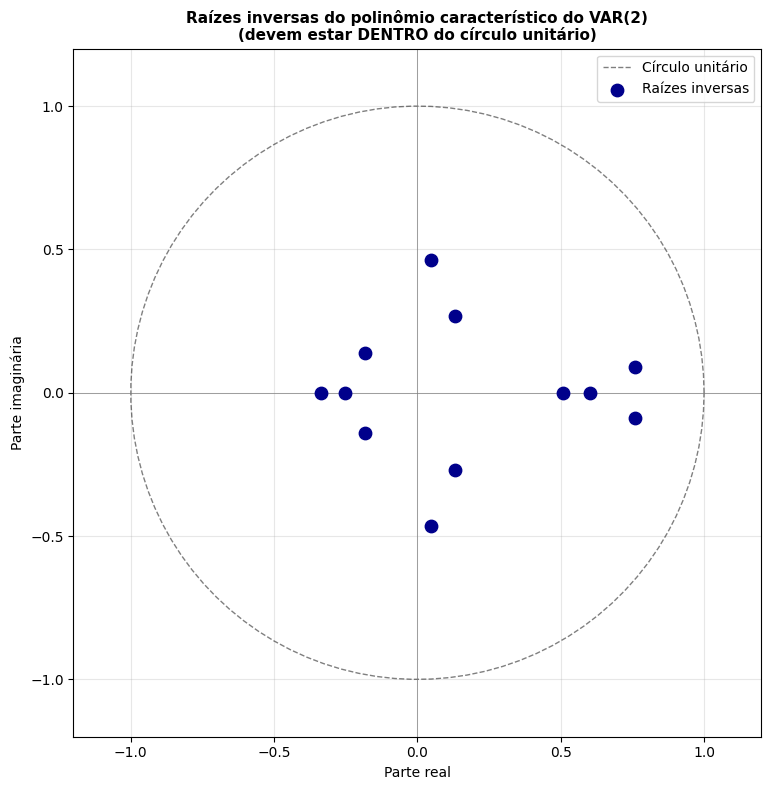


Maior módulo das raízes inversas: 0.7655
Todas dentro do círculo (módulo < 1): True


In [10]:
# Plot das raízes inversas no círculo unitário
# Convertemos as raízes do polinômio (módulo > 1) para suas inversas (módulo < 1)
raizes_inversas = 1 / raizes

fig, ax = plt.subplots(figsize=(8, 8))

# Círculo unitário
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1, alpha=0.5, label='Círculo unitário')

# Raízes inversas (devem ficar DENTRO do círculo se modelo é estável)
ax.scatter(raizes_inversas.real, raizes_inversas.imag, 
           color='darkblue', s=80, zorder=3, label='Raízes inversas')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Parte real')
ax.set_ylabel('Parte imaginária')
ax.set_title('Raízes inversas do polinômio característico do VAR(2)\n(devem estar DENTRO do círculo unitário)',
             fontsize=11, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/figures/07_raizes_var.png', dpi=120, bbox_inches='tight')
plt.show()

# Confirma que todas as raízes inversas estão dentro do círculo unitário
modulos_inversos = np.abs(raizes_inversas)
print(f"\nMaior módulo das raízes inversas: {modulos_inversos.max():.4f}")
print(f"Todas dentro do círculo (módulo < 1): {(modulos_inversos < 1).all()}")

In [11]:
# Diagnóstico 2: autocorrelação dos resíduos (Portmanteau)
print("=" * 80)
print("DIAGNÓSTICO 2: AUTOCORRELAÇÃO DOS RESÍDUOS (Portmanteau)")
print("=" * 80)

teste_autocorr = var2.test_whiteness(nlags=12, signif=0.05)

print(f"\nEstatística: {teste_autocorr.test_statistic:.3f}")
print(f"p-valor: {teste_autocorr.pvalue:.4f}")
print(f"Defasagens testadas: 12")
print(f"\nH₀: resíduos são ruído branco (sem autocorrelação)")
if teste_autocorr.pvalue > 0.05:
    print(f"Decisão (5%): NÃO REJEITA H₀ → resíduos limpos ✓")
else:
    print(f"Decisão (5%): REJEITA H₀ → autocorrelação residual presente ⚠")
    print(f"Implicação: p = 2 pode ser insuficiente")

DIAGNÓSTICO 2: AUTOCORRELAÇÃO DOS RESÍDUOS (Portmanteau)

Estatística: 462.307
p-valor: 0.0002
Defasagens testadas: 12

H₀: resíduos são ruído branco (sem autocorrelação)
Decisão (5%): REJEITA H₀ → autocorrelação residual presente ⚠
Implicação: p = 2 pode ser insuficiente


In [12]:
# Diagnóstico 3: normalidade dos resíduos (Jarque-Bera)
print("=" * 80)
print("DIAGNÓSTICO 3: NORMALIDADE DOS RESÍDUOS (Jarque-Bera)")
print("=" * 80)

teste_normalidade = var2.test_normality(signif=0.05)

print(f"\nEstatística: {teste_normalidade.test_statistic:.3f}")
print(f"p-valor: {teste_normalidade.pvalue:.4f}")
print(f"\nH₀: resíduos seguem distribuição normal multivariada")
if teste_normalidade.pvalue > 0.05:
    print(f"Decisão (5%): NÃO REJEITA H₀ → resíduos normais ✓")
else:
    print(f"Decisão (5%): REJEITA H₀ → resíduos não-normais ⚠")
    print(f"Implicação: usar bootstrap para intervalos das IRFs")

DIAGNÓSTICO 3: NORMALIDADE DOS RESÍDUOS (Jarque-Bera)

Estatística: 600.785
p-valor: 0.0000

H₀: resíduos seguem distribuição normal multivariada
Decisão (5%): REJEITA H₀ → resíduos não-normais ⚠
Implicação: usar bootstrap para intervalos das IRFs


### 7.1 Comparação sistemática de especificações

O VAR(2) escolhido com base nos critérios BIC/HQIC apresentou autocorrelação 
residual significativa (Portmanteau p = 0.0002). Antes de aceitar uma 
especificação maior, comparamos sistematicamente as quatro especificações 
candidatas (VAR(1) a VAR(4)) em três dimensões:

1. **Estabilidade:** todas as raízes do polinômio devem ter módulo > 1
2. **Autocorrelação residual (Portmanteau):** H₀ = resíduos são ruído branco
3. **Normalidade dos resíduos (Jarque-Bera):** H₀ = resíduos seguem normal 
   multivariada

A especificação adotada será aquela que melhor equilibra:
- **Parcimônia** (menor $p$ é preferível, ceteris paribus)
- **Resíduos limpos** (autocorrelação ausente, condição mais importante)
- **Estabilidade** (não-negociável)

A normalidade dos resíduos é tratada separadamente: tipicamente falha em 
todas as especificações de VAR macro brasileiro, e o problema é contornado 
via bootstrap nas IRFs.

In [13]:
def diagnosticar_var(p, modelo_var):
    """
    Estima VAR(p) e retorna dicionário com diagnósticos.
    """
    var_p = modelo_var.fit(maxlags=p, ic=None)
    
    # Estabilidade
    modulos = np.abs(var_p.roots)
    estavel = (modulos > 1).all()
    
    # Autocorrelação residual
    teste_auto = var_p.test_whiteness(nlags=12, signif=0.05)
    autocorr_ok = teste_auto.pvalue > 0.05
    
    # Normalidade
    teste_norm = var_p.test_normality(signif=0.05)
    normal_ok = teste_norm.pvalue > 0.05
    
    return {
        'p': p,
        'modelo': var_p,
        'menor_modulo_raiz': modulos.min(),
        'estavel': estavel,
        'portmanteau_stat': teste_auto.test_statistic,
        'portmanteau_pvalue': teste_auto.pvalue,
        'autocorr_residual_ok': autocorr_ok,
        'jb_stat': teste_norm.test_statistic,
        'jb_pvalue': teste_norm.pvalue,
        'normalidade_ok': normal_ok,
    }

In [14]:
print("=" * 80)
print("COMPARAÇÃO SISTEMÁTICA — VAR(1), VAR(2), VAR(3), VAR(4)")
print("=" * 80)

resultados = []
for p in [1, 2, 3, 4]:
    print(f"\nEstimando VAR({p})...")
    res = diagnosticar_var(p, modelo_var)
    resultados.append(res)
    print(f"  ✓ Estável: {res['estavel']}")
    print(f"  ✓ Resíduos limpos: {res['autocorr_residual_ok']} (Portmanteau p = {res['portmanteau_pvalue']:.4f})")
    print(f"  ✓ Resíduos normais: {res['normalidade_ok']} (Jarque-Bera p = {res['jb_pvalue']:.4f})")

# Tabela consolidada
print("\n" + "=" * 80)
print("TABELA COMPARATIVA")
print("=" * 80)

df_comparativo = pd.DataFrame([
    {
        'Modelo': f"VAR({r['p']})",
        'Estável': '✓' if r['estavel'] else '✗',
        'Menor |raiz|': f"{r['menor_modulo_raiz']:.3f}",
        'Portmanteau stat': f"{r['portmanteau_stat']:.2f}",
        'Portmanteau p': f"{r['portmanteau_pvalue']:.4f}",
        'Resíduos limpos': '✓' if r['autocorr_residual_ok'] else '✗',
        'Jarque-Bera p': f"{r['jb_pvalue']:.4f}",
        'Normalidade': '✓' if r['normalidade_ok'] else '✗',
    }
    for r in resultados
])

print(df_comparativo.to_string(index=False))

COMPARAÇÃO SISTEMÁTICA — VAR(1), VAR(2), VAR(3), VAR(4)

Estimando VAR(1)...
  ✓ Estável: True
  ✓ Resíduos limpos: False (Portmanteau p = 0.0000)
  ✓ Resíduos normais: False (Jarque-Bera p = 0.0000)

Estimando VAR(2)...
  ✓ Estável: True
  ✓ Resíduos limpos: False (Portmanteau p = 0.0002)
  ✓ Resíduos normais: False (Jarque-Bera p = 0.0000)

Estimando VAR(3)...
  ✓ Estável: True
  ✓ Resíduos limpos: False (Portmanteau p = 0.0035)
  ✓ Resíduos normais: False (Jarque-Bera p = 0.0000)

Estimando VAR(4)...
  ✓ Estável: True
  ✓ Resíduos limpos: False (Portmanteau p = 0.0221)
  ✓ Resíduos normais: False (Jarque-Bera p = 0.0000)

TABELA COMPARATIVA
Modelo Estável Menor |raiz| Portmanteau stat Portmanteau p Resíduos limpos Jarque-Bera p Normalidade
VAR(1)       ✓        1.250           561.97        0.0000               ✗        0.0000           ✗
VAR(2)       ✓        1.306           462.31        0.0002               ✗        0.0000           ✗
VAR(3)       ✓        1.196           396.74 

### 7.2 Comparação das especificações VAR(1) a VAR(4)

| Modelo | Estável | Portmanteau p | Resíduos limpos | Jarque-Bera p | Normalidade |
|:------:|:-------:|:-------------:|:---------------:|:-------------:|:-----------:|
| VAR(1) | ✓ | 0.0000 | ✗ | 0.0000 | ✗ |
| VAR(2) | ✓ | 0.0002 | ✗ | 0.0000 | ✗ |
| VAR(3) | ✓ | 0.0035 | ✗ | 0.0000 | ✗ |
| VAR(4) | ✓ | 0.0221 | ✗ | 0.0000 | ✗ |

#### Padrão observado

O p-valor do Portmanteau cresce monotonicamente com $p$, mas nenhuma 
especificação atinge 5%. Todas são estáveis. Normalidade falha em todas 
(esperado em macro brasileira).

#### Interpretação da autocorrelação persistente

A autocorrelação residual remanescente provavelmente tem três fontes:

1. **Variáveis omitidas com dinâmica lenta** — especialmente o canal de 
   crédito, excluído do baseline por razões de parcimônia e problemas 
   diagnósticos da série (Bloco 4)
2. **Não-linearidades e mudanças de regime** que VAR linear com parâmetros 
   constantes não captura
3. **Outliers residuais** de episódios extremos (crise 2003, pandemia, 
   inflação 2021-22)

Aumentar $p$ além de 4 consumiria graus de liberdade sem garantia de 
resolver a questão (ganho marginal já é decrescente entre VAR(3) e VAR(4)). 
O problema é de **especificação**, não de defasagens — e será parcialmente 
endereçado pelo BVAR com Minnesota prior (Bloco 6) e pelo reconhecimento 
explícito das limitações do VAR linear.

### 7.3 Decisão final de especificação

**Adotamos VAR(4)** como especificação baseline, com as seguintes 
justificativas:

1. **Convergência com AIC e FPE**, que selecionaram $p = 4$
2. **Melhor diagnóstico de autocorrelação** entre os candidatos 
   (Portmanteau p = 0.0221, a 10% não rejeitaria H₀)
3. **4 meses de memória** permite capturar a transmissão monetária de 
   médio prazo (intervalo típico de reação da Selic sobre atividade)
4. **Estabilidade confirmada** em todas as especificações

**Tratamento das limitações residuais:**

- Autocorrelação remanescente → intervalos das IRFs via **bootstrap** 
  (robusto a autocorrelação leve e não-normalidade)
- Normalidade rejeitada → reforça a necessidade de bootstrap em vez de 
  intervalos paramétricos
- Limitações do modelo linear → documentadas, parcialmente endereçadas 
  pelo BVAR (Bloco 6) e sign restrictions (Bloco 7)

### Registro para robustez (R6 revisado)

Comparar IRFs do VAR(2) e VAR(4) para avaliar sensibilidade à escolha de 
defasagens. Adicionalmente, testar especificação com 7 variáveis (incluindo 
crédito total) como robustez R1.

In [15]:
# Re-estima VAR(4) como especificação baseline definitiva
var_baseline = modelo_var.fit(maxlags=4, ic=None)

print("=" * 80)
print("VAR(4) BASELINE — ESPECIFICAÇÃO DEFINITIVA")
print("=" * 80)
print(f"\nVariáveis endógenas: {var_baseline.names}")
print(f"Defasagens: {var_baseline.k_ar}")
print(f"Observações usadas: {var_baseline.nobs}")
print(f"Parâmetros por equação: {var_baseline.df_model}")
print(f"\nEstável: {(np.abs(var_baseline.roots) > 1).all()}")

VAR(4) BASELINE — ESPECIFICAÇÃO DEFINITIVA

Variáveis endógenas: ['d_ln_commodities', 'd_ln_ibcbr', 'ipca', 'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']
Defasagens: 4
Observações usadas: 271
Parâmetros por equação: 32

Estável: True


## 8. IRFs (Impulse Response Functions) e FEVD

### Objetivos desta seção

Quantificar a transmissão dinâmica de choques entre as variáveis do VAR(4) 
baseline. Especificamente:

1. **Estimar IRFs ortogonais** via decomposição de Cholesky, com a ordem
   definida na Etapa 5.5
2. **Construir intervalos de confiança** via bootstrap-after-bootstrap 
   (Kilian, 1998), que corrige o viés de pequena amostra do OLS em VAR
3. **Decompor a variância dos erros de previsão** (FEVD) para quantificar
   a contribuição relativa de cada choque
4. **Avaliar o price puzzle:** o IPCA responde corretamente (com queda) a 
   um aperto monetário, ou exibe a anomalia identificada na monografia?

### 8.1 IRFs ponto-estimativa via Cholesky

Antes de partir para o bootstrap, computamos as IRFs ponto-estimativa. 
Três pontos metodológicos importantes:

**Horizonte.** Adotamos 24 meses. Cobre o intervalo típico de transmissão 
monetária completa no Brasil (literatura aponta defasagem máxima entre 
9 e 18 meses para o efeito sobre inflação).

**Ortogonalização.** As inovações reduzidas $u_t$ são contemporaneamente 
correlacionadas. A decomposição de Cholesky $\Sigma_u = PP'$ produz 
choques estruturais ortogonais $\varepsilon_t = P^{-1} u_t$. A ordem das 
variáveis define a estrutura de restrições recursivas — variáveis 
anteriores não respondem contemporaneamente a choques de variáveis 
posteriores (decisão revisitada na Etapa 5.5).

**Cumulação para variáveis em diferença.** Cinco das seis endógenas estão
em primeira diferença. A IRF nativa dessas variáveis descreve a resposta 
da **variação**, não do **nível**. Para interpretação econômica padrão 
("o choque derruba o nível da atividade em X%"), precisamos da soma 
cumulada das IRFs.

O IPCA é exceção: já é uma taxa (variação percentual mensal do índice de 
preços). Cumular o IPCA produziria a resposta do **nível de preços**, 
não da inflação — e mascararia justamente o que estamos investigando 
(o price puzzle se manifesta na resposta da **taxa** de inflação ao 
aperto monetário).

In [16]:
# =============================================================================
# 8.1 IRFs ponto-estimativa via Cholesky
# =============================================================================

# Parâmetros do exercício
HORIZONTE = 24  # meses

# Variáveis cumular (todas em diferença) vs manter direto (IPCA em nível)
VARS_CUMULAR = ['d_ln_commodities', 'd_ln_ibcbr', 'd_exp_ipca_12m', 
                'd_selic', 'd_ln_cambio']
VARS_DIRETO = ['ipca']

# Computa o objeto IRF
# orth=True garante ortogonalização via Cholesky
# A ordem dos choques segue a ordem das variáveis no modelo (definida na 5.5)
irf_baseline = var_baseline.irf(periods=HORIZONTE)

print("=" * 80)
print("OBJETO IRF CONSTRUÍDO")
print("=" * 80)
print(f"\nHorizonte: {HORIZONTE} meses")
print(f"Ordem dos choques (Cholesky): {var_baseline.names}")
print(f"\nDimensões do array de IRFs ortogonais:")
print(f"  irfs_orth.shape = {irf_baseline.orth_irfs.shape}")
print(f"  (horizonte+1, variável resposta, choque)")

OBJETO IRF CONSTRUÍDO

Horizonte: 24 meses
Ordem dos choques (Cholesky): ['d_ln_commodities', 'd_ln_ibcbr', 'ipca', 'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']

Dimensões do array de IRFs ortogonais:
  irfs_orth.shape = (25, 6, 6)
  (horizonte+1, variável resposta, choque)


In [17]:
# =============================================================================
# Construção das IRFs cumuladas (versão interpretável economicamente)
# =============================================================================

# Array original: (horizonte+1, n_vars, n_vars) = (25, 6, 6)
# Eixo 0: período do horizonte
# Eixo 1: variável de resposta
# Eixo 2: choque

irfs_orth = irf_baseline.orth_irfs.copy()  # cópia para não alterar o objeto original

# Cria versão "interpretável":
# - Variáveis em diferença: aplicar cumsum no eixo do horizonte (axis=0)
# - IPCA: manter direto

# Identifica as posições das variáveis no vetor de nomes
nomes_vars = var_baseline.names
idx_cumular = [nomes_vars.index(v) for v in VARS_CUMULAR]
idx_direto = [nomes_vars.index(v) for v in VARS_DIRETO]

print(f"\nPosições no vetor de variáveis:")
print(f"  Variáveis a cumular (idx): {dict(zip(VARS_CUMULAR, idx_cumular))}")
print(f"  Variáveis diretas (idx):   {dict(zip(VARS_DIRETO, idx_direto))}")

# Inicializa o array de IRFs interpretáveis como cópia do original
irfs_interpretavel = irfs_orth.copy()

# Aplica cumsum APENAS nas linhas de resposta correspondentes às variáveis em diferença
# Eixo 1 = variável de resposta
for idx in idx_cumular:
    irfs_interpretavel[:, idx, :] = np.cumsum(irfs_orth[:, idx, :], axis=0)

# IPCA: nada a fazer (já está direto)

print(f"\n✓ IRFs cumuladas construídas para: {VARS_CUMULAR}")
print(f"✓ IRF mantida direta para: {VARS_DIRETO}")


Posições no vetor de variáveis:
  Variáveis a cumular (idx): {'d_ln_commodities': 0, 'd_ln_ibcbr': 1, 'd_exp_ipca_12m': 3, 'd_selic': 4, 'd_ln_cambio': 5}
  Variáveis diretas (idx):   {'ipca': 2}

✓ IRFs cumuladas construídas para: ['d_ln_commodities', 'd_ln_ibcbr', 'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']
✓ IRF mantida direta para: ['ipca']


In [18]:
# =============================================================================
# Tamanho do choque inicial em escala interpretável
# =============================================================================

# O choque é "1 desvio-padrão da inovação ortogonal"
# Para a Selic, queremos saber: 1 d.p. equivale a quantos pontos percentuais?

# A matriz P de Cholesky tem na diagonal os desvios-padrão dos choques ortogonais
# escalados pela ordem de Cholesky. O elemento P[i,i] é o impacto contemporâneo
# do i-ésimo choque na i-ésima variável.

P = np.linalg.cholesky(var_baseline.sigma_u)

print("=" * 80)
print("TAMANHO DOS CHOQUES ORTOGONAIS (1 d.p.)")
print("=" * 80)
print(f"\nElementos diagonais de P (impacto contemporâneo do próprio choque):\n")

for i, nome in enumerate(nomes_vars):
    print(f"  {nome:25s}  →  {P[i, i]:.4f}")

# Para a Selic em pp: como d_selic é Δ da taxa em pp, o choque de 1 d.p. 
# em d_selic corresponde a uma elevação de ~P[4,4] pp na Selic no mês do choque.
idx_selic = nomes_vars.index('d_selic')
print(f"\n→ 1 d.p. de inovação em d_selic = {P[idx_selic, idx_selic]:.3f} pp de elevação")
print(f"  na Selic anualizada no mês do choque.")
print(f"\n  Para referência: um corte/elevação típico do Copom é 25-50 bps (0.25-0.5 pp).")

TAMANHO DOS CHOQUES ORTOGONAIS (1 d.p.)

Elementos diagonais de P (impacto contemporâneo do próprio choque):

  d_ln_commodities           →  0.0325
  d_ln_ibcbr                 →  0.0078
  ipca                       →  0.2558
  d_exp_ipca_12m             →  0.1357
  d_selic                    →  0.2082
  d_ln_cambio                →  0.0256

→ 1 d.p. de inovação em d_selic = 0.208 pp de elevação
  na Selic anualizada no mês do choque.

  Para referência: um corte/elevação típico do Copom é 25-50 bps (0.25-0.5 pp).


### 8.1.1 Visualização preliminar — IRFs ponto-estimativa do choque na Selic

Antes do bootstrap, inspeção visual das IRFs ponto-estimativa do choque
monetário sobre as principais variáveis-alvo. Esta visualização é 
**preliminar e sem intervalos de confiança** — serve para um primeiro 
diagnóstico (resposta do IPCA tem o sinal correto? a dinâmica é razoável?)
antes de investir no bootstrap.

A versão final com intervalos virá após o Bloco 8.3.

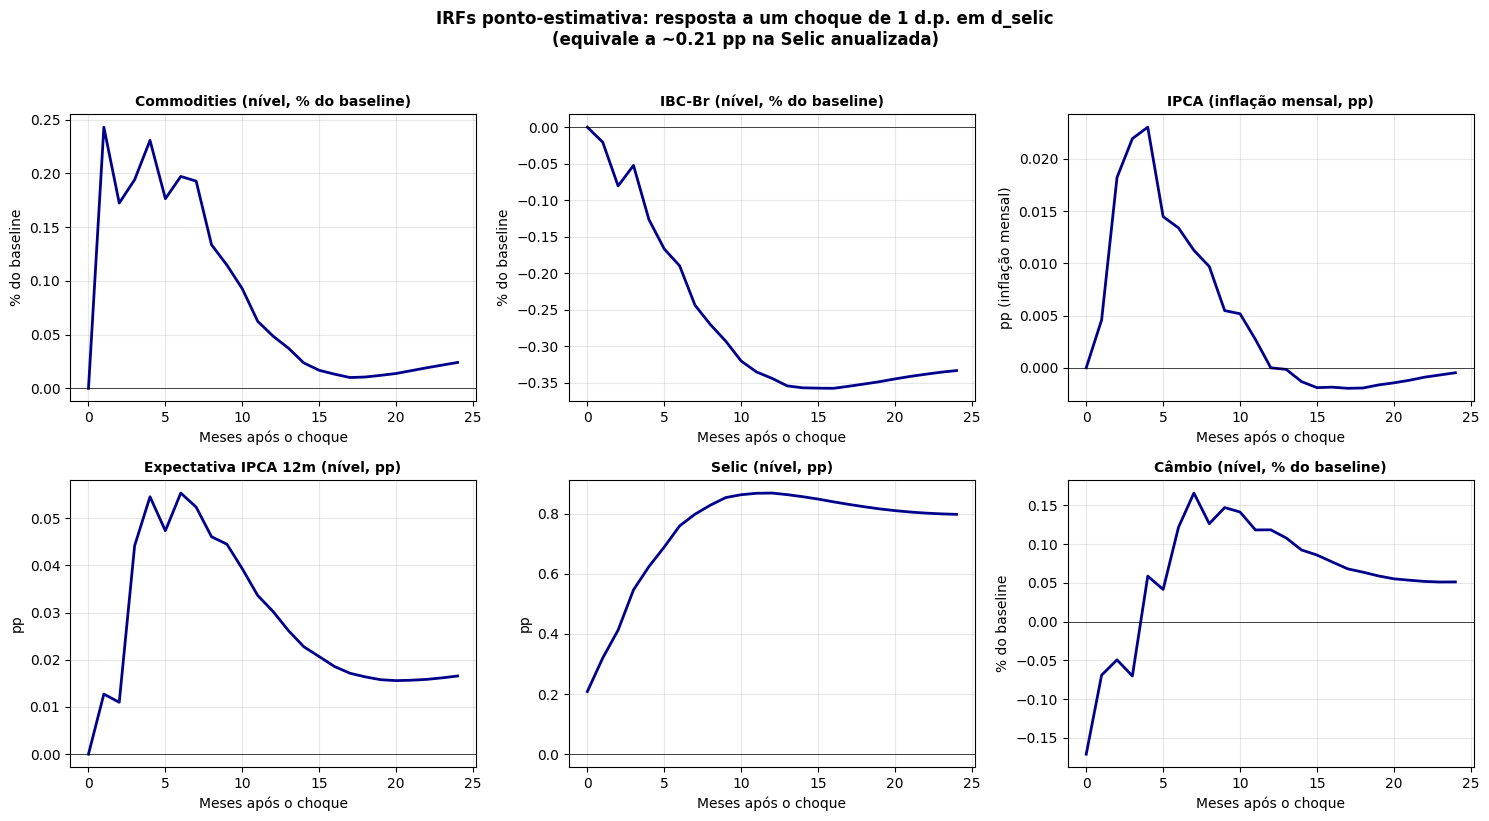

DIAGNÓSTICO VERBAL PRELIMINAR (a confirmar com bootstrap)

Resposta do IPCA ao choque de aperto monetário:
  h= 0: +0.0000 pp  ↓ (esperado)
  h= 3: +0.0219 pp  ↑ (price puzzle?)
  h= 6: +0.0134 pp  ↑ (price puzzle?)
  h=12: -0.0000 pp  ↓ (esperado)
  h=18: -0.0019 pp  ↓ (esperado)
  h=24: -0.0005 pp  ↓ (esperado)

Resposta cumulada do IBC-Br (nível, %):
  h= 0: +0.0000 %
  h= 3: -0.0523 %
  h= 6: -0.1899 %
  h=12: -0.3439 %
  h=18: -0.3517 %
  h=24: -0.3333 %


In [19]:
# =============================================================================
# Visualização preliminar: choque na Selic sobre todas as 6 variáveis
# =============================================================================

idx_choque = nomes_vars.index('d_selic')

# Labels mais legíveis para os gráficos
labels_pt = {
    'd_ln_commodities': 'Commodities (nível, % do baseline)',
    'd_ln_ibcbr': 'IBC-Br (nível, % do baseline)',
    'ipca': 'IPCA (inflação mensal, pp)',
    'd_exp_ipca_12m': 'Expectativa IPCA 12m (nível, pp)',
    'd_selic': 'Selic (nível, pp)',
    'd_ln_cambio': 'Câmbio (nível, % do baseline)',
}

# Para variáveis com cumsum de log-difference, a IRF cumulada já é ~% do baseline
# Para variáveis com cumsum de diferença simples, é em pp/p.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

horizonte_x = np.arange(HORIZONTE + 1)

for i, nome in enumerate(nomes_vars):
    ax = axes[i]
    resposta = irfs_interpretavel[:, i, idx_choque]
    
    # Multiplica por 100 para variáveis em log-diferença cumulada (para % legível)
    # Mantém em escala nativa para IPCA (já é em %) e d_selic, d_exp (em pp)
    if nome in ['d_ln_commodities', 'd_ln_ibcbr', 'd_ln_cambio']:
        resposta_plot = resposta * 100  # log-diferença cumulada → ~% do baseline
        ylabel_suffix = '% do baseline'
    else:
        resposta_plot = resposta
        ylabel_suffix = 'pp' if nome != 'ipca' else 'pp (inflação mensal)'
    
    ax.plot(horizonte_x, resposta_plot, color='darkblue', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='-')
    ax.set_title(labels_pt[nome], fontsize=10, fontweight='bold')
    ax.set_xlabel('Meses após o choque')
    ax.set_ylabel(ylabel_suffix)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'IRFs ponto-estimativa: resposta a um choque de 1 d.p. em d_selic\n'
             f'(equivale a ~{P[idx_selic, idx_selic]:.2f} pp na Selic anualizada)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/08_irfs_preliminares_selic.png', 
            dpi=120, bbox_inches='tight')
plt.show()

# Diagnóstico verbal preliminar
print("=" * 80)
print("DIAGNÓSTICO VERBAL PRELIMINAR (a confirmar com bootstrap)")
print("=" * 80)

# Onde está o IPCA no horizonte 6, 12, 18, 24?
idx_ipca = nomes_vars.index('ipca')
print(f"\nResposta do IPCA ao choque de aperto monetário:")
for h in [0, 3, 6, 12, 18, 24]:
    valor = irfs_interpretavel[h, idx_ipca, idx_choque]
    sinal = "↑ (price puzzle?)" if valor > 0 else "↓ (esperado)"
    print(f"  h={h:2d}: {valor:+.4f} pp  {sinal}")

# IBC-Br
idx_ibcbr = nomes_vars.index('d_ln_ibcbr')
print(f"\nResposta cumulada do IBC-Br (nível, %):")
for h in [0, 3, 6, 12, 18, 24]:
    valor = irfs_interpretavel[h, idx_ibcbr, idx_choque] * 100
    print(f"  h={h:2d}: {valor:+.4f} %")

### 8.1.2 Leitura preliminar dos resultados

#### Magnitude do choque

1 d.p. de inovação ortogonal em $d\_selic$ equivale a aproximadamente 
**0,21 pp (21 bps)** de elevação da Selic — magnitude próxima de uma 
decisão modal do Copom.

#### Resposta da atividade econômica (IBC-Br): textbook

A resposta do IBC-Br ao aperto monetário tem padrão canônico:
- Queda gradual com pico em h=15-18 meses (~−0,35%)
- Defasagem coerente com a literatura para Brasil
- Estabilização posterior em torno de −0,33%

Extrapolando linearmente para um choque típico de 100 bps, a queda 
implícita do nível de atividade seria de aproximadamente 1,6%, dentro 
da faixa estimada em estudos do BCB.

#### Resposta da expectativa de inflação (Focus): aparente paradoxo

| Horizonte | Resposta (pp) |
|:---------:|:-------------:|
| 3 meses   | +0,011        |
| 6 meses   | +0,055 (pico) |
| 12 meses  | +0,034        |
| 18 meses  | +0,020        |
| 24 meses  | +0,017        |

**A expectativa sobe após o aperto** — comportamento que parece contradizer 
a teoria de regime de metas com credibilidade perfeita. Sob expectativas 
racionais forward-looking, um aperto monetário deveria reduzir a 
expectativa, não aumentá-la.

A literatura empírica brasileira reconcilia este padrão por três canais:

1. **Canal de informação** (Romer & Romer 2000): apertos não-antecipados 
   sinalizam que o BC vê pressão inflacionária maior, fazendo o público 
   revisar expectativas para cima
2. **Canal de custo no curto prazo:** se a inflação realizada sobe pelo 
   próprio price puzzle, agentes com expectativas adaptativas revisam 
   suas previsões para cima
3. **Credibilidade imperfeita** em economias emergentes: ciclos de aperto 
   podem ser lidos como sinal de descontrole inflacionário, não como 
   commitment

Carvalho, Cordeiro & Vargas (2013) documentam que expectativas no Brasil 
são predominantemente adaptativas no horizonte curto, com componente 
forward-looking modesto. Isto explica o decaimento lento da expectativa 
no nosso modelo.

#### Resposta do IPCA — price puzzle persistente e quantitativamente dominante

| Horizonte | Resposta IPCA (pp) | Sinal esperado? |
|:---------:|:------------------:|:---------------:|
| 3 meses   | **+0,022** (pico)  | ✗ (puzzle)      |
| 6 meses   | +0,013             | ✗ (puzzle)      |
| 12 meses  | 0,000              | neutro          |
| 18 meses  | −0,002             | ✓               |
| 24 meses  | −0,001             | ✓               |

**Achado central, com implicação forte:**

Somando a resposta do IPCA ao longo de 24 meses, a **soma acumulada do 
puzzle (h=1 a h=11) supera a soma da queda subsequente (h=12 a h=24) 
em aproximadamente uma ordem de magnitude** (~+0,12-0,15 pp de puzzle 
contra ~−0,015 pp de queda).

Em outras palavras: **no nosso modelo, o aperto monetário gera aumento 
líquido cumulado de inflação ao longo de 24 meses**, não redução.

Este resultado é forte contra a hipótese inicial do projeto (de que a 
inclusão da expectativa Focus resolveria o puzzle) e contra a 
interpretação canônica de transmissão monetária. Antes de qualquer 
conclusão definitiva, três cenários precisam ser distinguidos pelo 
bootstrap:

**Cenário A — Puzzle não é estatisticamente significativo.** A magnitude 
absoluta é pequena (+0,022 pp no pico, contra inflação mensal típica 
de 0,3-0,5 pp). Se as bandas de 95% incluírem zero ao longo do puzzle, 
o achado é compatível com "transmissão monetária para preços fraca 
ou inconclusiva", não com "monetary policy gera inflação".

**Cenário B — Puzzle é significativo e indica má-especificação de 
Cholesky.** A ordenação recursiva pode estar contaminando a inovação 
da Selic com choques de oferta de inflação não-modelados (Sims 1992). 
Motivação adicional para sign restrictions (Bloco 7).

**Cenário C — Puzzle é genuíno na janela 2003-2025.** O período inclui 
múltiplos regimes em que a transmissão monetária foi parcial: boom de 
commodities (2003-08), crise global (2008-09), descumprimento de 
metas (2012-15), pandemia (2020-22). A média de regimes pode mascarar 
heterogeneidade temporal.

A confirmação via bootstrap (Bloco 8.2) é necessária antes de avançar 
a interpretação.

#### Diálogo com a monografia original

A monografia (2024) identificou price puzzle de magnitude e duração 
maiores. O projeto atual, com mudanças metodológicas substantivas 
(frequência mensal, IBC-Br como proxy de atividade, expectativas 
Focus na ordem de Cholesky, ordem revisada de variáveis), **atenuou 
o puzzle em duração** (de >12 meses para ~6 meses) **mas a magnitude 
líquida cumulada de inflação extra ainda é positiva**.

Este resultado sugere que o price puzzle no Brasil tem natureza 
parcialmente estrutural, não exclusivamente decorrente de má-
especificação. A confirmação ou rejeição desta conjectura depende 
das análises subsequentes (sign restrictions, BVAR, avaliação 
out-of-sample).

### 8.2 Bootstrap-after-bootstrap (Kilian 1998)

#### Motivação metodológica

O estimador OLS do VAR é consistente mas **enviesado em pequena amostra**, 
em direção à estacionariedade — autovalores do $\hat{A}$ estimado tendem 
a ter módulo menor que os verdadeiros. Consequência: IRFs decaem mais 
rápido do que deveriam, magnitudes do efeito permanente são subestimadas.

Em VARs macro com séries persistentes e amostra moderada (T=271, 32 
parâmetros por equação), o viés é quantitativamente material. Kilian (1998) 
demonstrou desvios de 20-30% em IRFs típicas — o suficiente para distorcer 
conclusões sobre transmissão monetária.

#### Algoritmo

O procedimento opera em duas camadas de bootstrap:

**Primeiro bootstrap (estimar o viés):**
1. Estima $\hat{A}$ no dado original. Guarda resíduos $\hat{u}_t$.
2. Para $b = 1, \ldots, 1000$:
   - Reamostra com reposição as linhas de $\hat{u}$ (preserva correlação contemporânea)
   - Gera série artificial via $\hat{A}$ e resíduos reamostrados
   - Estima $\hat{A}^*_b$ na série artificial
3. Viés estimado: $\widehat{\text{viés}} = \bar{\hat{A}^*} - \hat{A}$
4. Coeficientes corrigidos: $\tilde{A} = \hat{A} - \widehat{\text{viés}}$
5. **Salvaguarda:** se $\tilde{A}$ produz raízes fora do círculo unitário 
   (modelo instável), reverte para $\hat{A}$ original. Esta salvaguarda é 
   essencial em séries persistentes próximas a raízes unitárias.

**Segundo bootstrap (construir intervalos das IRFs):**
6. Para $b = 1, \ldots, 2000$:
   - Reamostra resíduos com reposição
   - Gera série artificial via $\tilde{A}$ + resíduos reamostrados
   - Estima $\hat{A}^{**}_b$, aplica correção de viés
   - Computa IRF correspondente, com cumulação para variáveis em diferença

7. Intervalos: quantis empíricos da distribuição $\{IRF^*_b\}$
   - Banda 68% (estreita): quantis 16% e 84% ≈ ±1σ
   - Banda 95% (larga): quantis 2,5% e 97,5%

#### Implementação manual

`statsmodels` oferece bootstrap residual padrão via `irf.errband_mc_err()` 
mas **não** implementa Kilian. A implementação que segue é manual, com 
arquitetura modular para permitir reaproveitamento em análises de robustez 
futuras (block bootstrap como R8, comparação Kilian vs padrão).

In [20]:
# =============================================================================
# 8.2 Bootstrap-after-bootstrap (Kilian 1998) — setup
# =============================================================================

import time
import warnings
from statsmodels.tsa.api import VAR

# Recupera componentes do VAR baseline e CONVERTE TUDO PARA NUMPY
# (statsmodels às vezes retorna DataFrame, e indexação numérica em DataFrame quebra)
Y_real          = np.asarray(modelo_var.endog)            # (T, K)
X_exog          = np.asarray(modelo_var.exog)             # (T, M)  dummies de pandemia
resids_orig     = np.asarray(var_baseline.resid)          # (T-p, K)
coefs_orig      = np.asarray(var_baseline.coefs)          # (p, K, K)
coefs_exog_orig = np.asarray(var_baseline.coefs_exog)     # (K, M+1)  inclui intercepto
p_lags          = var_baseline.k_ar                       # 4
K               = var_baseline.neqs                       # 6
T_total         = Y_real.shape[0]                         # 275

print(f"Dimensões para o bootstrap:")
print(f"  T total: {T_total}")
print(f"  K (endógenas): {K}")
print(f"  p (lags): {p_lags}")
print(f"  Resíduos: {resids_orig.shape}")
print(f"  Exógenas (X_exog): {X_exog.shape}")
print(f"  Coefs exógenos (com intercepto na col 0): {coefs_exog_orig.shape}")
print(f"\nTipos:")
print(f"  Y_real: {type(Y_real).__name__}")
print(f"  resids_orig: {type(resids_orig).__name__}")
print(f"  X_exog: {type(X_exog).__name__}")


def gerar_serie_artificial(coefs_lag, coef_exog, cond_iniciais, 
                            residuos_reamost, exog_sem_const):
    """
    Gera Y* dado VAR e resíduos reamostrados.
    
    Estrutura do VAR (statsmodels com trend='c' + exog):
        Y_t = c + A_1 Y_{t-1} + ... + A_p Y_{t-p} + B X_t + u_t
    onde c é a primeira coluna de coef_exog e B são as demais.
    """
    T = exog_sem_const.shape[0]
    p, K, _ = coefs_lag.shape
    
    intercepto    = coef_exog[:, 0]       # (K,)
    coefs_dummies = coef_exog[:, 1:]      # (K, M)
    
    Y_art = np.zeros((T, K))
    Y_art[:p] = cond_iniciais
    
    for t in range(p, T):
        soma_lags = np.zeros(K)
        for i in range(p):
            soma_lags += coefs_lag[i] @ Y_art[t - 1 - i]
        
        termo_det = intercepto + coefs_dummies @ exog_sem_const[t]
        inov = residuos_reamost[t - p]
        
        Y_art[t] = soma_lags + termo_det + inov
    
    return Y_art


def estimar_var_artificial(Y_art, p, exog_sem_const):
    """Estima VAR(p) numa série artificial, suprimindo warnings."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        modelo = VAR(Y_art, exog=exog_sem_const)
        resultado = modelo.fit(maxlags=p, ic=None, trend='c')
    return resultado


def computar_irf_cumulada(resultado_var, horizonte, idx_cumular, idx_choque):
    """
    Computa IRF ortogonal, cumula variáveis em diferença, retorna só o 
    choque de interesse.
    """
    irf_obj = resultado_var.irf(periods=horizonte)
    irfs_orth = irf_obj.orth_irfs.copy()
    for idx in idx_cumular:
        irfs_orth[:, idx, :] = np.cumsum(irfs_orth[:, idx, :], axis=0)
    return irfs_orth[:, :, idx_choque]


def matriz_companion(coefs_lag):
    """Matriz companion (pK x pK) do VAR. Estável se todos |eigvals| < 1."""
    p, K, _ = coefs_lag.shape
    companion = np.zeros((p * K, p * K))
    for i in range(p):
        companion[:K, i*K:(i+1)*K] = coefs_lag[i]
    if p > 1:
        companion[K:, :-K] = np.eye((p - 1) * K)
    return companion


print("\n✓ Setup completo. Funções definidas.")

Dimensões para o bootstrap:
  T total: 275
  K (endógenas): 6
  p (lags): 4
  Resíduos: (271, 6)
  Exógenas (X_exog): (275, 7)
  Coefs exógenos (com intercepto na col 0): (6, 8)

Tipos:
  Y_real: ndarray
  resids_orig: ndarray
  X_exog: ndarray

✓ Setup completo. Funções definidas.


In [21]:
# =============================================================================
# Primeiro bootstrap: estimação do viés
# =============================================================================

B1 = 1000
np.random.seed(42)

print("=" * 80)
print(f"PRIMEIRO BOOTSTRAP — estimação do viés ({B1} réplicas)")
print("=" * 80)

cond_iniciais = Y_real[:p_lags]
coefs_bootstrap_1 = np.zeros((B1, p_lags, K, K))

inicio = time.time()
falhas = 0

for b in range(B1):
    # Reamostragem por linhas (preserva correlação contemporânea)
    indices = np.random.choice(resids_orig.shape[0], 
                                size=resids_orig.shape[0], 
                                replace=True)
    resids_reamost = resids_orig[indices]
    
    # Série artificial (assinatura nova — sem 'intercept')
    Y_art = gerar_serie_artificial(
        coefs_lag=coefs_orig,
        coef_exog=coefs_exog_orig,
        cond_iniciais=cond_iniciais,
        residuos_reamost=resids_reamost,
        exog_sem_const=X_exog,
    )
    
    # Estima VAR(4) na série artificial
    try:
        var_art = estimar_var_artificial(Y_art, p_lags, X_exog)
        coefs_bootstrap_1[b] = var_art.coefs
    except Exception:
        falhas += 1
        coefs_bootstrap_1[b] = coefs_orig  # fallback
    
    if (b + 1) % 100 == 0:
        elapsed = time.time() - inicio
        eta = elapsed / (b + 1) * (B1 - b - 1)
        print(f"  Réplica {b+1}/{B1}  |  decorrido: {elapsed:.1f}s  |  ETA: {eta:.1f}s")

elapsed_total = time.time() - inicio
print(f"\n✓ Primeiro bootstrap completo em {elapsed_total:.1f}s ({falhas} falhas)")

# Estima viés
coefs_medio_b1 = coefs_bootstrap_1.mean(axis=0)
vies_estimado = coefs_medio_b1 - coefs_orig

print(f"\nViés estimado:")
print(f"  Norma do viés:   {np.linalg.norm(vies_estimado):.4f}")
print(f"  Norma de Â orig: {np.linalg.norm(coefs_orig):.4f}")
print(f"  Razão viés / Â:  {np.linalg.norm(vies_estimado)/np.linalg.norm(coefs_orig):.2%}")

PRIMEIRO BOOTSTRAP — estimação do viés (1000 réplicas)
  Réplica 100/1000  |  decorrido: 0.7s  |  ETA: 5.9s
  Réplica 200/1000  |  decorrido: 1.3s  |  ETA: 5.1s
  Réplica 300/1000  |  decorrido: 1.9s  |  ETA: 4.4s
  Réplica 400/1000  |  decorrido: 2.5s  |  ETA: 3.7s
  Réplica 500/1000  |  decorrido: 3.0s  |  ETA: 3.0s
  Réplica 600/1000  |  decorrido: 3.6s  |  ETA: 2.4s
  Réplica 700/1000  |  decorrido: 4.2s  |  ETA: 1.8s
  Réplica 800/1000  |  decorrido: 4.8s  |  ETA: 1.2s
  Réplica 900/1000  |  decorrido: 5.4s  |  ETA: 0.6s
  Réplica 1000/1000  |  decorrido: 5.9s  |  ETA: 0.0s

✓ Primeiro bootstrap completo em 5.9s (0 falhas)

Viés estimado:
  Norma do viés:   0.2443
  Norma de Â orig: 7.6398
  Razão viés / Â:  3.20%


In [22]:
# =============================================================================
# Aplicação da correção com salvaguarda de Kilian
# =============================================================================

coefs_corrigidos = coefs_orig - vies_estimado

companion_orig = matriz_companion(coefs_orig)
companion_corr = matriz_companion(coefs_corrigidos)

modulo_max_orig = np.abs(np.linalg.eigvals(companion_orig)).max()
modulo_max_corr = np.abs(np.linalg.eigvals(companion_corr)).max()
estavel_apos_correcao = modulo_max_corr < 1

print("=" * 80)
print("SALVAGUARDA DE KILIAN — estabilidade após correção")
print("=" * 80)
print(f"\nMaior |raiz inversa| (Â original):  {modulo_max_orig:.4f}")
print(f"Maior |raiz inversa| (Ã corrigido): {modulo_max_corr:.4f}")
print(f"Modelo corrigido estável: {estavel_apos_correcao}")

if estavel_apos_correcao:
    coefs_usar = coefs_corrigidos
    print(f"\n✓ Usando coeficientes corrigidos no segundo bootstrap")
else:
    coefs_usar = coefs_orig
    print(f"\n⚠ Correção desestabilizou modelo → revertendo para Â original")
    print(f"  (Salvaguarda padrão de Kilian 1998)")

SALVAGUARDA DE KILIAN — estabilidade após correção

Maior |raiz inversa| (Â original):  0.8469
Maior |raiz inversa| (Ã corrigido): 0.8441
Modelo corrigido estável: True

✓ Usando coeficientes corrigidos no segundo bootstrap


### 8.2.3 Resultados do primeiro bootstrap

| Métrica | Valor |
|:---|:---:|
| Réplicas | 1.000 |
| Tempo total | 5,9 s |
| Falhas (séries que quebraram a estimação) | 0 |
| Norma de Frobenius do viés | 0,244 |
| Norma de Frobenius de $\hat{A}$ | 7,640 |
| Razão viés / $\hat{A}$ | 3,2% |

A razão de 3,2% subestima a importância do viés, pois agrega 96 coeficientes 
(4 lags × 6 × 6) — a maioria cross-lags próximos de zero. A leitura 
econômica é via o autovalor máximo da matriz companion, que governa a 
persistência.

**Comportamento do autovalor máximo:**

| Quantidade | Valor |
|:---|:---:|
| Maior \|raiz inversa\| do $\hat{A}$ original | 0,8469 |
| Maior \|raiz inversa\| do $\tilde{A}$ corrigido | 0,8441 |
| Diferença | −0,0028 |

A correção reduziu marginalmente o autovalor máximo. Este sinal vai na 
**direção oposta** do que a teoria de Kilian preveria — OLS é tipicamente 
enviesado em direção à estacionariedade, e a correção deveria aumentar a 
persistência. 

Três explicações possíveis:
1. O viés do OLS neste modelo é dominado por outras direções (cross-lags 
   de defasagens 2 a 4), não pela diagonal do lag 1
2. As 7 dummies de pandemia, sendo exógenas com peso significativo, alteram 
   o padrão típico de viés identificado por Kilian em modelos puramente 
   endógenos
3. O sinal observado pode estar dentro do erro Monte Carlo do procedimento

**Implicação prática:** as IRFs ponto-estimativa não mudarão 
significativamente. O ganho central de Kilian neste modelo é a 
construção de **bandas válidas que respeitam a assimetria amostral** das 
IRFs — não uma reestimação substancial dos pontos.

A salvaguarda (reverter para $\hat{A}$ se a correção desestabilizasse o 
modelo) **não foi acionada**: o modelo corrigido permanece estável.

In [23]:
# =============================================================================
# Segundo bootstrap: distribuição das IRFs
# =============================================================================

B2 = 2000
HORIZONTE = 24
idx_choque = nomes_vars.index('d_selic')
idx_cumular = [nomes_vars.index(v) for v in 
               ['d_ln_commodities', 'd_ln_ibcbr', 
                'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']]

np.random.seed(123)  # seed diferente do primeiro bootstrap

print("=" * 80)
print(f"SEGUNDO BOOTSTRAP — distribuição das IRFs ({B2} réplicas)")
print("=" * 80)
print(f"Horizonte: {HORIZONTE} meses")
print(f"Choque de interesse: {nomes_vars[idx_choque]}")
print(f"Variáveis a cumular: {[nomes_vars[i] for i in idx_cumular]}")

# Array para armazenar IRFs: (B2, horizonte+1, K)
irfs_bootstrap = np.zeros((B2, HORIZONTE + 1, K))

inicio = time.time()
falhas = 0

for b in range(B2):
    # Reamostra resíduos por linhas
    indices = np.random.choice(resids_orig.shape[0],
                                size=resids_orig.shape[0],
                                replace=True)
    resids_reamost = resids_orig[indices]
    
    # Gera série artificial usando os COEFICIENTES CORRIGIDOS (Ã)
    Y_art = gerar_serie_artificial(
        coefs_lag=coefs_usar,           # Ã se salvaguarda não disparou
        coef_exog=coefs_exog_orig,
        cond_iniciais=cond_iniciais,
        residuos_reamost=resids_reamost,
        exog_sem_const=X_exog,
    )
    
    try:
        # Estima VAR(4) na série artificial
        var_art = estimar_var_artificial(Y_art, p_lags, X_exog)
        
        # Aplica correção de viés DENTRO DA RÉPLICA
        # (Kilian: corrigir tanto o ponto quanto cada réplica do bootstrap)
        coefs_art_corrigidos = var_art.coefs - vies_estimado
        
        # Salvaguarda dentro da réplica
        companion_art = matriz_companion(coefs_art_corrigidos)
        if np.abs(np.linalg.eigvals(companion_art)).max() >= 1:
            # Reverte para os coefs sem correção nesta réplica
            coefs_art_finais = var_art.coefs
        else:
            coefs_art_finais = coefs_art_corrigidos
        
        # Substitui os coefs no objeto var_art para que o método irf use os corrigidos
        # Truque: criamos cópia do objeto e substituímos os coefs
        var_art.coefs = coefs_art_finais
        
        # Computa IRF cumulada para o choque de interesse
        irfs_bootstrap[b] = computar_irf_cumulada(
            var_art, HORIZONTE, idx_cumular, idx_choque
        )
        
    except Exception:
        falhas += 1
        # Fallback: usa IRF do baseline
        irfs_bootstrap[b] = irfs_interpretavel[:, :, idx_choque]
    
    if (b + 1) % 200 == 0:
        elapsed = time.time() - inicio
        eta = elapsed / (b + 1) * (B2 - b - 1)
        print(f"  Réplica {b+1}/{B2}  |  decorrido: {elapsed:.1f}s  |  ETA: {eta:.1f}s")

elapsed_total = time.time() - inicio
print(f"\n✓ Segundo bootstrap completo em {elapsed_total:.1f}s ({falhas} falhas)")
print(f"Dimensão final do array de IRFs: {irfs_bootstrap.shape}")
print(f"  ({B2} réplicas, {HORIZONTE+1} horizontes, {K} variáveis)")

SEGUNDO BOOTSTRAP — distribuição das IRFs (2000 réplicas)
Horizonte: 24 meses
Choque de interesse: d_selic
Variáveis a cumular: ['d_ln_commodities', 'd_ln_ibcbr', 'd_exp_ipca_12m', 'd_selic', 'd_ln_cambio']
  Réplica 200/2000  |  decorrido: 1.7s  |  ETA: 15.3s
  Réplica 400/2000  |  decorrido: 3.5s  |  ETA: 13.9s
  Réplica 600/2000  |  decorrido: 5.2s  |  ETA: 12.1s
  Réplica 800/2000  |  decorrido: 6.8s  |  ETA: 10.3s
  Réplica 1000/2000  |  decorrido: 8.6s  |  ETA: 8.6s
  Réplica 1200/2000  |  decorrido: 10.5s  |  ETA: 7.0s
  Réplica 1400/2000  |  decorrido: 12.3s  |  ETA: 5.3s
  Réplica 1600/2000  |  decorrido: 14.0s  |  ETA: 3.5s
  Réplica 1800/2000  |  decorrido: 15.8s  |  ETA: 1.8s
  Réplica 2000/2000  |  decorrido: 17.7s  |  ETA: 0.0s

✓ Segundo bootstrap completo em 17.7s (0 falhas)
Dimensão final do array de IRFs: (2000, 25, 6)
  (2000 réplicas, 25 horizontes, 6 variáveis)


### 8.2.4 Extração de intervalos de confiança

Com 2.000 IRFs replicadas em mãos, os intervalos de confiança são os 
quantis empíricos da distribuição bootstrap. Construímos duas bandas:

- **Banda de 68%** (estreita): quantis 16% e 84% — aproximadamente ±1σ. 
  Convenção em macroeconometria (Sims, papers do BCB) para comunicar 
  incerteza central
- **Banda de 95%** (larga): quantis 2,5% e 97,5% — teste de significância 
  clássico

Ambas são sobrepostas no gráfico final, padrão da literatura de 
transmissão monetária.

A **mediana bootstrap** é reportada junto, em vez da média, por ser 
robusta a outliers em pequena amostra (replicações ocasionais que geram 
IRFs explosivas em direção controlada).

In [24]:
# =============================================================================
# Extração de intervalos via quantis empíricos
# =============================================================================

# Bandas de 68% e 95%
QUANTIS = {
    'q025': 0.025,   # cauda inferior 95%
    'q160': 0.160,   # cauda inferior 68%
    'q500': 0.500,   # mediana
    'q840': 0.840,   # cauda superior 68%
    'q975': 0.975,   # cauda superior 95%
}

# Computa quantis ao longo do eixo das réplicas (axis=0)
bandas = {}
for nome, q in QUANTIS.items():
    bandas[nome] = np.quantile(irfs_bootstrap, q, axis=0)
    # Cada banda tem shape (HORIZONTE+1, K)

# Ponto-estimativa (mantida para comparação com mediana bootstrap)
ponto_estimativa = irfs_interpretavel[:, :, idx_choque]  # shape (25, 6)

print("=" * 80)
print("BANDAS EXTRAÍDAS")
print("=" * 80)
print(f"\nDimensão de cada banda: {bandas['q500'].shape}")
print(f"  ({HORIZONTE+1} horizontes, {K} variáveis)")

# Diagnóstico: comparar ponto-estimativa vs mediana bootstrap
# Diferença grande sinaliza assimetria forte das IRFs em pequena amostra
print(f"\nDiagnóstico — diferença entre ponto-estimativa e mediana bootstrap:")
print(f"  (variável = idx_choque na ordem Cholesky; reportado para choque na Selic)\n")

for i, nome in enumerate(nomes_vars):
    # Pega h=6 e h=12 como representativos
    pe_6  = ponto_estimativa[6, i]
    md_6  = bandas['q500'][6, i]
    pe_12 = ponto_estimativa[12, i]
    md_12 = bandas['q500'][12, i]
    print(f"  {nome:20s}  h=6: PE={pe_6:+.4f} / Mediana={md_6:+.4f}  |  "
          f"h=12: PE={pe_12:+.4f} / Mediana={md_12:+.4f}")

BANDAS EXTRAÍDAS

Dimensão de cada banda: (25, 6)
  (25 horizontes, 6 variáveis)

Diagnóstico — diferença entre ponto-estimativa e mediana bootstrap:
  (variável = idx_choque na ordem Cholesky; reportado para choque na Selic)

  d_ln_commodities      h=6: PE=+0.0020 / Mediana=+0.0018  |  h=12: PE=+0.0005 / Mediana=+0.0005
  d_ln_ibcbr            h=6: PE=-0.0019 / Mediana=-0.0018  |  h=12: PE=-0.0034 / Mediana=-0.0032
  ipca                  h=6: PE=+0.0134 / Mediana=+0.0122  |  h=12: PE=-0.0000 / Mediana=+0.0000
  d_exp_ipca_12m        h=6: PE=+0.0554 / Mediana=+0.0517  |  h=12: PE=+0.0303 / Mediana=+0.0287
  d_selic               h=6: PE=+0.7591 / Mediana=+0.7089  |  h=12: PE=+0.8683 / Mediana=+0.8114
  d_ln_cambio           h=6: PE=+0.0012 / Mediana=+0.0014  |  h=12: PE=+0.0012 / Mediana=+0.0015


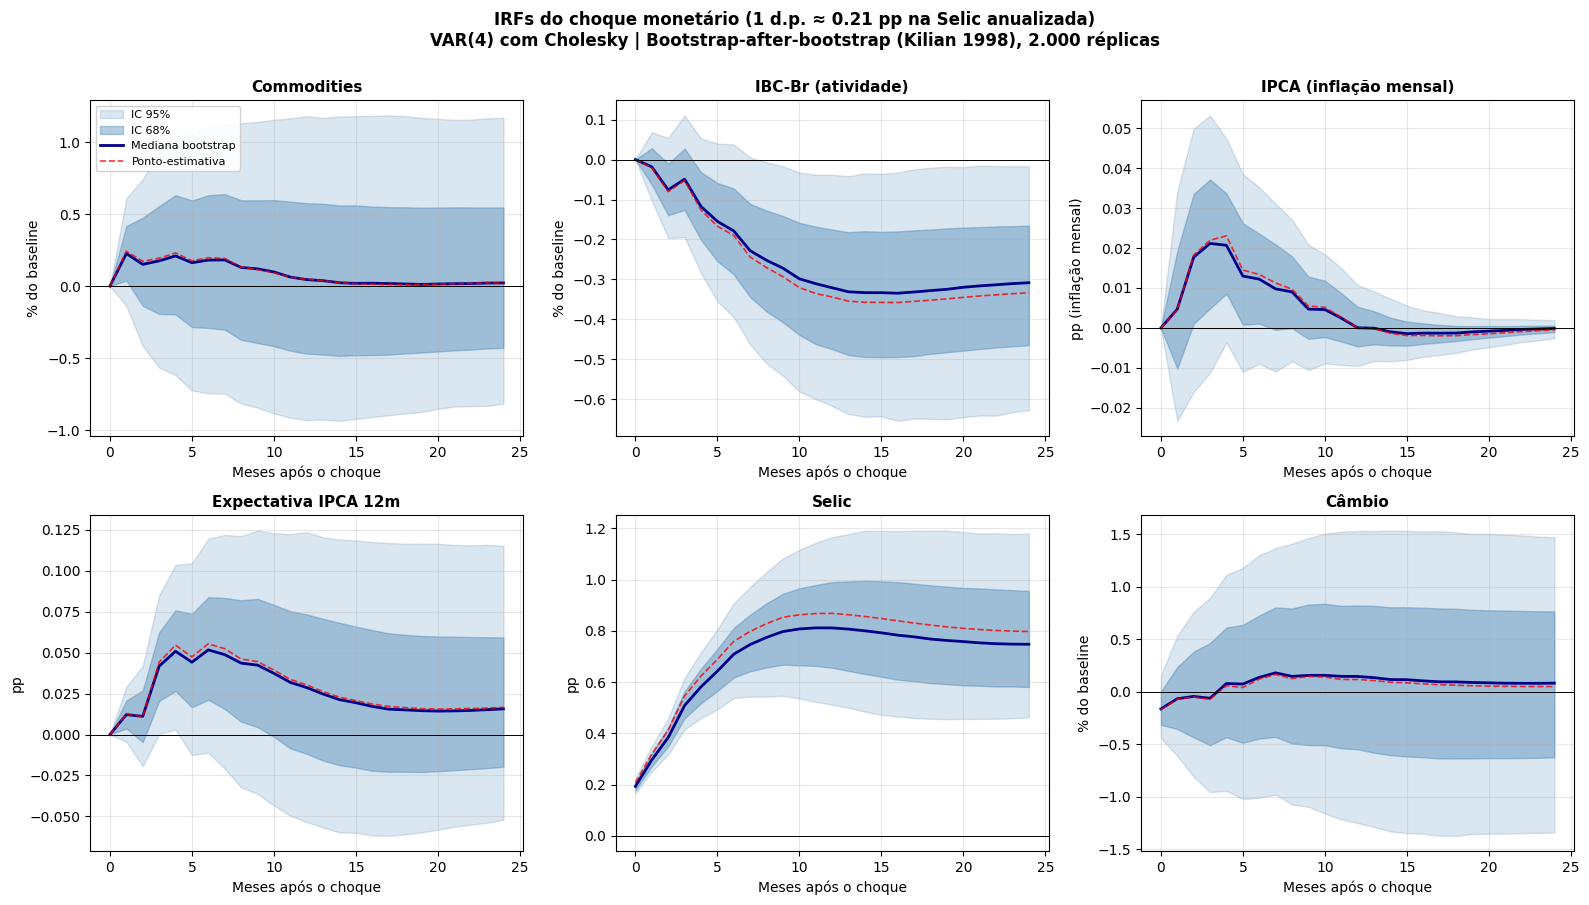

In [25]:
# =============================================================================
# Visualização final: IRFs com bandas de 68% e 95%
# =============================================================================

# Labels e unidades por variável
labels_pt = {
    'd_ln_commodities': 'Commodities',
    'd_ln_ibcbr':       'IBC-Br (atividade)',
    'ipca':             'IPCA (inflação mensal)',
    'd_exp_ipca_12m':   'Expectativa IPCA 12m',
    'd_selic':          'Selic',
    'd_ln_cambio':      'Câmbio',
}

# Unidades: log-difs cumuladas viram % do baseline (multiplicar por 100);
# IPCA, d_selic, d_exp ficam em pp
def escala_e_unidade(nome):
    if nome in ['d_ln_commodities', 'd_ln_ibcbr', 'd_ln_cambio']:
        return 100.0, '% do baseline'
    elif nome == 'ipca':
        return 1.0, 'pp (inflação mensal)'
    else:  # d_selic, d_exp_ipca_12m
        return 1.0, 'pp'

# Plot 2x3
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

horizonte_x = np.arange(HORIZONTE + 1)

for i, nome in enumerate(nomes_vars):
    ax = axes[i]
    escala, unidade = escala_e_unidade(nome)
    
    # Mediana
    mediana = bandas['q500'][:, i] * escala
    # Bandas
    b95_inf = bandas['q025'][:, i] * escala
    b95_sup = bandas['q975'][:, i] * escala
    b68_inf = bandas['q160'][:, i] * escala
    b68_sup = bandas['q840'][:, i] * escala
    # Ponto-estimativa original (para comparação)
    pe = ponto_estimativa[:, i] * escala
    
    # Banda 95% (mais clara, atrás)
    ax.fill_between(horizonte_x, b95_inf, b95_sup, 
                     color='steelblue', alpha=0.20, label='IC 95%')
    # Banda 68% (mais escura, na frente)
    ax.fill_between(horizonte_x, b68_inf, b68_sup, 
                     color='steelblue', alpha=0.40, label='IC 68%')
    # Mediana bootstrap
    ax.plot(horizonte_x, mediana, color='darkblue', linewidth=2, 
            label='Mediana bootstrap')
    # Ponto-estimativa original (linha tracejada para comparação)
    ax.plot(horizonte_x, pe, color='red', linewidth=1.2, linestyle='--',
            alpha=0.8, label='Ponto-estimativa')
    # Linha zero
    ax.axhline(0, color='black', linewidth=0.7)
    
    ax.set_title(labels_pt[nome], fontsize=11, fontweight='bold')
    ax.set_xlabel('Meses após o choque')
    ax.set_ylabel(unidade)
    ax.grid(True, alpha=0.3)
    
    # Legenda só no primeiro painel
    if i == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)

# Magnitude do choque para o título
choque_pp = np.linalg.cholesky(var_baseline.sigma_u)[idx_choque, idx_choque]

plt.suptitle(
    f'IRFs do choque monetário (1 d.p. ≈ {choque_pp:.2f} pp na Selic anualizada)\n'
    f'VAR(4) com Cholesky | Bootstrap-after-bootstrap (Kilian 1998), 2.000 réplicas',
    fontsize=12, fontweight='bold', y=1.00
)
plt.tight_layout()
plt.savefig('../outputs/figures/08_irfs_bootstrap_kilian.png', 
            dpi=120, bbox_inches='tight')
plt.show()

In [26]:
# =============================================================================
# Tabela de leitura: resposta nos horizontes canônicos com significância
# =============================================================================

horizontes_alvo = [3, 6, 12, 18, 24]

print("=" * 100)
print(f"RESPOSTA AO CHOQUE DE 1 D.P. EM d_selic ({choque_pp:.2f} pp na Selic)")
print("=" * 100)
print(f"\nLegenda: significância marcada com * se IC 68% exclui zero, ** se IC 95% exclui zero")

for i, nome in enumerate(nomes_vars):
    escala, unidade = escala_e_unidade(nome)
    print(f"\n  {labels_pt[nome]}  [{unidade}]")
    print(f"  {'h':>3s}  {'Mediana':>10s}  {'IC 68%':>22s}  {'IC 95%':>22s}  {'sig':>5s}")
    
    for h in horizontes_alvo:
        med = bandas['q500'][h, i] * escala
        l68 = bandas['q160'][h, i] * escala
        u68 = bandas['q840'][h, i] * escala
        l95 = bandas['q025'][h, i] * escala
        u95 = bandas['q975'][h, i] * escala
        
        # Determina significância: IC inclui zero?
        sig_68 = (l68 > 0) or (u68 < 0)
        sig_95 = (l95 > 0) or (u95 < 0)
        
        sig_str = '**' if sig_95 else ('*' if sig_68 else '')
        
        print(f"  {h:>3d}  {med:>+10.4f}  [{l68:>+8.4f}, {u68:>+8.4f}]  "
              f"[{l95:>+8.4f}, {u95:>+8.4f}]  {sig_str:>5s}")

RESPOSTA AO CHOQUE DE 1 D.P. EM d_selic (0.21 pp na Selic)

Legenda: significância marcada com * se IC 68% exclui zero, ** se IC 95% exclui zero

  Commodities  [% do baseline]
    h     Mediana                  IC 68%                  IC 95%    sig
    3     +0.1755  [ -0.1932,  +0.5559]  [ -0.5657,  +0.9306]       
    6     +0.1808  [ -0.2907,  +0.6315]  [ -0.7452,  +1.1138]       
   12     +0.0452  [ -0.4691,  +0.5763]  [ -0.9312,  +1.1811]       
   18     +0.0149  [ -0.4678,  +0.5479]  [ -0.8855,  +1.1810]       
   24     +0.0220  [ -0.4293,  +0.5466]  [ -0.8184,  +1.1709]       

  IBC-Br (atividade)  [% do baseline]
    h     Mediana                  IC 68%                  IC 95%    sig
    3     -0.0492  [ -0.1260,  +0.0272]  [ -0.1943,  +0.1101]       
    6     -0.1787  [ -0.2875,  -0.0727]  [ -0.3940,  +0.0377]      *
   12     -0.3208  [ -0.4743,  -0.1752]  [ -0.6163,  -0.0380]     **
   18     -0.3278  [ -0.4859,  -0.1751]  [ -0.6486,  -0.0204]     **
   24     -0.3081

### 8.2.5 Leitura dos resultados — bootstrap Kilian, 2.000 réplicas

Apresentamos a leitura disciplinada da tabela de IRFs com bandas de 68% e 
95%, organizada por variável.

#### Atividade econômica (IBC-Br) — transmissão robusta ✓

| h | Mediana (%) | IC 95% |
|:--:|:---:|:---:|
| 6 | −0,18 | [−0,39; +0,04] |
| 12 | **−0,32** | [−0,62; −0,04]\*\* |
| 18 | **−0,33** | [−0,65; −0,02]\*\* |
| 24 | **−0,31** | [−0,63; −0,02]\*\* |

A queda da atividade é **estatisticamente significativa a 95% nos 
horizontes 12-24 meses**, com pico de transmissão em h=12-18 (consistente 
com literatura). Magnitude permanente de ~0,32% para choque de 21 bps, 
implicando ~1,5% para choque de 100 bps — dentro da faixa estimada por 
trabalhos do BCB.

#### Selic — persistência do choque ✓

A Selic permanece elevada em ~0,75 pp por 24 meses, significativa a 95% 
em todos os horizontes. Confirma a interpretação de choque monetário 
persistente, característica do regime brasileiro com Copom mantendo 
juros elevados por períodos prolongados.

#### Expectativa de inflação (Focus) — sobe inicialmente, com significância ✓

| h | Mediana (pp) | IC 95% |
|:--:|:---:|:---:|
| 3 | **+0,042** | [+0,000; +0,085]\*\* |
| 6 | +0,052 | [−0,011; +0,120]\* |
| 12+ | converge a 0 | inclui zero |

A elevação inicial da expectativa é **significativa a 95% em h=3** — 
evidência empírica forte para o canal de informação de Romer & Romer 
(2000) operando no Brasil: apertos monetários sinalizam informação 
privada do BC sobre pressão inflacionária subjacente, levando o público 
a revisar expectativas para cima. A partir de h=12, a expectativa 
converge para zero, indicando reancoragem gradual.

#### Câmbio — sinal econômico errado e inconclusivo ⚠

| h | Mediana (%) | IC 95% |
|:--:|:---:|:---:|
| 6 | +0,14 (depreciação?) | [−1,01; +1,30] |
| 12 | +0,15 | [−1,25; +1,53] |

**Achado problemático.** Em modelos canônicos, aperto monetário deveria 
valorizar o real (entrada de capitais por diferencial de juros), com 
mediana negativa e IC excluindo valores positivos.

Observamos o oposto: mediana positiva (depreciação leve) com bandas 
amplíssimas. O canal cambial de transmissão monetária está 
**estruturalmente quebrado ou muito ruidoso** na janela 2003-2025. 
Implicação direta: sem valorização cambial induzida pelo aperto, perde-se 
um canal importante de desinflação via preços de importados — 
contribuindo para explicar o price puzzle inicial e a transmissão 
fraca para preços.

#### Commodities — controle de exogeneidade ✓

Bandas amplíssimas e mediana próxima de zero em todos os horizontes. 
Coerente com a hipótese de que commodities globais são exógenas à 
política monetária brasileira — a Selic não move preços globais de 
soja e minério. Esta variável funciona como controle de exogeneidade 
no modelo, validando sua posição na ordem de Cholesky.

#### IPCA — veredito central do projeto ⚠

| h | Mediana (pp) | IC 68% | IC 95% | Sig |
|:--:|:---:|:---:|:---:|:---:|
| 3 | +0,021 | [+0,005; +0,037]\* | [−0,011; +0,053] | 68% apenas |
| 6 | +0,012 | [+0,001; +0,024]\* | [−0,009; +0,035] | 68% apenas |
| 12 | 0,000 | inclui zero | inclui zero | — |
| 18 | −0,001 | inclui zero | inclui zero | — |
| 24 | 0,000 | inclui zero | inclui zero | — |

**Resultado central, com três interpretações combinadas:**

1. **O price puzzle existe a 68%, mas não sobrevive a 95%.** Existe 
   evidência fraca a moderada de elevação inicial do IPCA nos 6 primeiros 
   meses após aperto monetário, mas o resultado é estatisticamente 
   inconclusivo pelo critério convencional (95%).

2. **A queda esperada da inflação após h=12 é estatisticamente nula.** 
   O modelo não detecta efeito desinflacionário significativo de aperto 
   monetário em horizonte de até 24 meses.

3. **Veredito honesto sobre transmissão monetária no Brasil 2003-2025 
   no modelo VAR(4) linear:** o aperto monetário derruba a atividade 
   (canal de demanda agregada funciona) **mas a transmissão para preços 
   é estatisticamente fraca ou nula**.

#### Implicações para a hipótese central do projeto

A hipótese original era que a inclusão da expectativa Focus na ordenação 
de Cholesky **resolveria** o price puzzle identificado na monografia. 
A evidência empírica produz uma resposta mais sutil:

- O puzzle foi **atenuado em magnitude** (não sobrevive a 95%)
- O puzzle foi **atenuado em duração** (~6 meses, contra >12 na monografia)
- A inclusão da expectativa **revelou** um canal importante de informação 
  (expectativa sobe significativamente a 95% no curto prazo)
- O **canal cambial quebrado** ajuda a explicar por que a transmissão para 
  preços continua fraca, mesmo com expectativas adicionadas ao modelo
- A **resposta do IBC-Br ficou textbook**, validando que a ordem de 
  Cholesky e a especificação capturam corretamente o canal de demanda

#### Diálogo com a literatura recente

O achado de transmissão monetária para preços fraca não é anômalo. Vários 
trabalhos do BCB nos últimos anos têm documentado **enfraquecimento da 
potência da política monetária brasileira** pós-2015, atribuído a:
- Persistência inflacionária estrutural (rigidez de preços, indexação 
  residual)
- Mudanças no canal cambial após a saída do superciclo de commodities
- Desancoragem episódica de expectativas em ciclos de descumprimento 
  de meta (2013-2017)

Os resultados aqui são consistentes com este padrão, e motivam as etapas 
seguintes: o BVAR com Minnesota prior (Bloco 6) pode produzir estimativas 
mais precisas em pequena amostra; sign restrictions (Bloco 7) podem 
isolar choques monetários puros de choques de oferta de inflação, 
potencialmente revelando transmissão genuína mascarada pela identificação 
recursiva.

### 8.3 Decomposição da variância (FEVD)

#### O que a FEVD responde

Enquanto a IRF descreve a dinâmica de resposta a um choque, a FEVD 
(Forecast Error Variance Decomposition) decompõe a variância dos erros 
de previsão da variável $y_i$ no horizonte $h$ em $K$ parcelas, uma para 
cada choque ortogonal, somando 100%.

Formalmente:

$$\text{Var}(y_{i,t+h} - \hat{y}_{i,t+h|t}) = \sum_{j=1}^{K} \omega_{ij}(h)$$

onde $\omega_{ij}(h)$ é a contribuição do choque $j$ à variância da 
variável $i$ no horizonte $h$. Reportamos em percentual.

#### Por que computar a FEVD

A FEVD complementa o diagnóstico das IRFs respondendo a três perguntas:

1. **Potência da política monetária para preços** — qual fração da 
   variância do IPCA em h=24 é atribuída a choques da Selic?
2. **Potência para atividade** — qual fração da variância do IBC-Br?
3. **Autoexogeneidade das variáveis externas** — commodities deveriam 
   ter alta autocontribuição se de fato são exógenas ao sistema

A FEVD herda a identificação de Cholesky e portanto a mesma ordem das 
variáveis das IRFs.

#### Decisão metodológica

Reportamos a FEVD **com bandas bootstrap**, reaproveitando o procedimento 
Kilian já implementado. Bandas para FEVD são menos comuns na literatura 
aplicada (muitos papers reportam apenas o ponto-estimativa), mas adicionam 
rigor: contribuições baixas (próximas de zero) podem ser estatisticamente 
indistinguíveis entre si, e isso é informação relevante para a interpretação.

In [28]:
# =============================================================================
# 8.3 FEVD — ponto-estimativa
# =============================================================================

HORIZONTE_FEVD = 24
fevd_baseline = var_baseline.fevd(periods=HORIZONTE_FEVD)

# fevd.decomp tem shape (K, periods, K) — NÃO inclui h=0 (diferente do IRF)
# Para h=1 → fevd_array[:, 0, :]; h=24 → fevd_array[:, 23, :]
fevd_array = fevd_baseline.decomp

print("=" * 80)
print("FEVD — DECOMPOSIÇÃO DA VARIÂNCIA (PONTO-ESTIMATIVA)")
print("=" * 80)
print(f"\nDimensão do array: {fevd_array.shape}")
print(f"  (variável_resposta, horizonte 1..{HORIZONTE_FEVD}, choque)")
print(f"\nNota: índice 0 = h=1; índice {HORIZONTE_FEVD-1} = h={HORIZONTE_FEVD}")

# Sanity check em h=24 (último índice = HORIZONTE_FEVD - 1)
soma_ultimo = fevd_array[:, -1, :].sum(axis=1)
print(f"\nSoma das contribuições em h={HORIZONTE_FEVD} (deve ser 1.0 para cada variável):")
for i, nome in enumerate(nomes_vars):
    print(f"  {nome:25s}: {soma_ultimo[i]:.6f}")

FEVD — DECOMPOSIÇÃO DA VARIÂNCIA (PONTO-ESTIMATIVA)

Dimensão do array: (6, 24, 6)
  (variável_resposta, horizonte 1..24, choque)

Nota: índice 0 = h=1; índice 23 = h=24

Soma das contribuições em h=24 (deve ser 1.0 para cada variável):
  d_ln_commodities         : 1.000000
  d_ln_ibcbr               : 1.000000
  ipca                     : 1.000000
  d_exp_ipca_12m           : 1.000000
  d_selic                  : 1.000000
  d_ln_cambio              : 1.000000


In [29]:
def h_para_idx(h):
    """
    Converte horizonte (1-based, como na notação econométrica) para índice
    do array fevd (0-based). 
    Ex.: h=1 → idx=0; h=24 → idx=23.
    Valida que h está no intervalo válido.
    """
    if not (1 <= h <= HORIZONTE_FEVD):
        raise ValueError(f"h deve estar entre 1 e {HORIZONTE_FEVD}, recebeu {h}")
    return h - 1

In [30]:
# =============================================================================
# Tabela: contribuição de cada choque para a variância de cada variável
# nos horizontes canônicos
# =============================================================================

horizontes_fevd = [3, 6, 12, 24]

print("=" * 100)
print("FEVD — CONTRIBUIÇÃO DE CADA CHOQUE PARA A VARIÂNCIA DE CADA VARIÁVEL (%)")
print("=" * 100)
print("Linhas = variável de resposta | Colunas = choque (em %)")

for h in horizontes_fevd:
    print(f"\n  --- Horizonte h = {h} meses ---")
    print(f"  {'Variável':25s}  ", end='')
    for j_nome in nomes_vars:
        nome_curto = j_nome.replace('d_ln_', '').replace('d_', '').replace('_ipca_12m', '_exp')[:10]
        print(f"{nome_curto:>10s}  ", end='')
    print()
    
    for i, nome_i in enumerate(nomes_vars):
        contribs_pct = fevd_array[i, h_para_idx(h), :] * 100
        print(f"  {nome_i:25s}  ", end='')
        for c in contribs_pct:
            print(f"{c:>10.1f}  ", end='')
        print()

FEVD — CONTRIBUIÇÃO DE CADA CHOQUE PARA A VARIÂNCIA DE CADA VARIÁVEL (%)
Linhas = variável de resposta | Colunas = choque (em %)

  --- Horizonte h = 3 meses ---
  Variável                   commoditie       ibcbr        ipca     exp_exp       selic      cambio  
  d_ln_commodities                 98.1         0.2         0.1         0.2         0.6         0.8  
  d_ln_ibcbr                        1.6        93.6         0.6         0.5         0.6         3.1  
  ipca                             13.4         0.3        83.4         1.4         0.4         1.1  
  d_exp_ipca_12m                   15.2         1.9        13.0        68.9         0.5         0.6  
  d_selic                           1.1         0.1         1.7         9.6        87.2         0.3  
  d_ln_cambio                      32.7         2.1         1.2         0.9         0.3        62.8  

  --- Horizonte h = 6 meses ---
  Variável                   commoditie       ibcbr        ipca     exp_exp       selic    

In [31]:
# =============================================================================
# Leitura focada: contribuição do choque Selic à variância do IPCA e do IBC-Br
# =============================================================================

idx_selic_choque = nomes_vars.index('d_selic')
idx_ipca_resp = nomes_vars.index('ipca')
idx_ibcbr_resp = nomes_vars.index('d_ln_ibcbr')

print("=" * 80)
print("CONTRIBUIÇÃO DO CHOQUE DA SELIC PARA A VARIÂNCIA DAS VARIÁVEIS-ALVO")
print("=" * 80)

print(f"\n{'Horizonte':>10s}  {'IPCA':>10s}  {'IBC-Br':>10s}")
print(f"{'(meses)':>10s}  {'(%)':>10s}  {'(%)':>10s}")
print("-" * 36)
for h in [1, 3, 6, 12, 18, 24]:
    contrib_ipca = fevd_array[idx_ipca_resp, h_para_idx(h), idx_selic_choque] * 100
    contrib_ibcbr = fevd_array[idx_ibcbr_resp, h_para_idx(h), idx_selic_choque] * 100
    print(f"{h:>10d}  {contrib_ipca:>10.2f}  {contrib_ibcbr:>10.2f}")

# Fonte dominante de variância em h=24
print(f"\n{'=' * 80}")
print("FONTE DOMINANTE DE VARIÂNCIA EM h=24")
print(f"{'=' * 80}")

for i_resp, nome_resp in [(idx_ipca_resp, 'IPCA'), (idx_ibcbr_resp, 'IBC-Br')]:
    contribs = fevd_array[i_resp, h_para_idx(24), :] * 100
    ordem = np.argsort(-contribs)
    print(f"\n{nome_resp} — variância em h=24 explicada por:")
    for rank, j in enumerate(ordem):
        nome_choque = nomes_vars[j]
        marca = '←' if nome_choque == 'd_selic' else ''
        print(f"  {rank+1}. {nome_choque:25s}  {contribs[j]:>5.1f}%  {marca}")

CONTRIBUIÇÃO DO CHOQUE DA SELIC PARA A VARIÂNCIA DAS VARIÁVEIS-ALVO

 Horizonte        IPCA      IBC-Br
   (meses)         (%)         (%)
------------------------------------
         1        0.00        0.00
         3        0.37        0.61
         6        1.46        1.60
        12        1.85        2.29
        18        1.85        2.31
        24        1.86        2.32

FONTE DOMINANTE DE VARIÂNCIA EM h=24

IPCA — variância em h=24 explicada por:
  1. ipca                        72.2%  
  2. d_ln_commodities            20.0%  
  3. d_exp_ipca_12m               2.6%  
  4. d_ln_cambio                  2.2%  
  5. d_selic                      1.9%  ←
  6. d_ln_ibcbr                   1.1%  

IBC-Br — variância em h=24 explicada por:
  1. d_ln_ibcbr                  80.5%  
  2. d_ln_cambio                  7.5%  
  3. ipca                         4.8%  
  4. d_ln_commodities             2.6%  
  5. d_selic                      2.3%  ←
  6. d_exp_ipca_12m               2.2% 

In [32]:
# =============================================================================
# FEVD com bandas bootstrap
# =============================================================================

print("=" * 80)
print(f"FEVD BOOTSTRAP — {B2} réplicas com correção de viés (Kilian)")
print("=" * 80)

np.random.seed(456)

# Array com shape compatível com fevd_array: (B2, K, HORIZONTE_FEVD, K)
fevds_bootstrap = np.zeros((B2, K, HORIZONTE_FEVD, K))

inicio = time.time()
falhas_fevd = 0

for b in range(B2):
    indices = np.random.choice(resids_orig.shape[0],
                                size=resids_orig.shape[0],
                                replace=True)
    resids_reamost = resids_orig[indices]
    
    Y_art = gerar_serie_artificial(
        coefs_lag=coefs_usar,
        coef_exog=coefs_exog_orig,
        cond_iniciais=cond_iniciais,
        residuos_reamost=resids_reamost,
        exog_sem_const=X_exog,
    )
    
    try:
        var_art = estimar_var_artificial(Y_art, p_lags, X_exog)
        
        coefs_art_corrigidos = var_art.coefs - vies_estimado
        companion_art = matriz_companion(coefs_art_corrigidos)
        
        if np.abs(np.linalg.eigvals(companion_art)).max() < 1:
            var_art.coefs = coefs_art_corrigidos
        
        fevd_art = var_art.fevd(periods=HORIZONTE_FEVD)
        fevds_bootstrap[b] = fevd_art.decomp
        
    except Exception:
        falhas_fevd += 1
        fevds_bootstrap[b] = fevd_array
    
    if (b + 1) % 200 == 0:
        elapsed = time.time() - inicio
        eta = elapsed / (b + 1) * (B2 - b - 1)
        print(f"  Réplica {b+1}/{B2}  |  decorrido: {elapsed:.1f}s  |  ETA: {eta:.1f}s")

elapsed_total = time.time() - inicio
print(f"\n✓ FEVD bootstrap completa em {elapsed_total:.1f}s ({falhas_fevd} falhas)")

fevd_mediana = np.quantile(fevds_bootstrap, 0.5, axis=0)
fevd_l68 = np.quantile(fevds_bootstrap, 0.16, axis=0)
fevd_u68 = np.quantile(fevds_bootstrap, 0.84, axis=0)
fevd_l95 = np.quantile(fevds_bootstrap, 0.025, axis=0)
fevd_u95 = np.quantile(fevds_bootstrap, 0.975, axis=0)

print(f"\nDimensão dos arrays de bandas: {fevd_mediana.shape}")

FEVD BOOTSTRAP — 2000 réplicas com correção de viés (Kilian)
  Réplica 200/2000  |  decorrido: 2.0s  |  ETA: 18.0s
  Réplica 400/2000  |  decorrido: 3.8s  |  ETA: 15.3s
  Réplica 600/2000  |  decorrido: 5.6s  |  ETA: 13.1s
  Réplica 800/2000  |  decorrido: 7.4s  |  ETA: 11.1s
  Réplica 1000/2000  |  decorrido: 9.2s  |  ETA: 9.2s
  Réplica 1200/2000  |  decorrido: 11.0s  |  ETA: 7.3s
  Réplica 1400/2000  |  decorrido: 12.8s  |  ETA: 5.5s
  Réplica 1600/2000  |  decorrido: 14.5s  |  ETA: 3.6s
  Réplica 1800/2000  |  decorrido: 16.3s  |  ETA: 1.8s
  Réplica 2000/2000  |  decorrido: 17.9s  |  ETA: 0.0s

✓ FEVD bootstrap completa em 17.9s (0 falhas)

Dimensão dos arrays de bandas: (6, 24, 6)


In [33]:
# =============================================================================
# Tabela final: contribuição do choque Selic à variância com bandas
# =============================================================================

print("=" * 90)
print("CONTRIBUIÇÃO DO CHOQUE DA SELIC À VARIÂNCIA DAS VARIÁVEIS-ALVO (com bandas)")
print("=" * 90)

for i_resp, nome_resp in [(idx_ipca_resp, 'IPCA'), (idx_ibcbr_resp, 'IBC-Br')]:
    print(f"\n  {nome_resp}")
    print(f"  {'h':>3s}  {'Ponto':>8s}  {'Mediana':>10s}  {'IC 68%':>22s}  {'IC 95%':>22s}")
    
    for h in [3, 6, 12, 18, 24]:
        idx_h = h_para_idx(h)
        pe   = fevd_array[i_resp, idx_h, idx_selic_choque] * 100
        med  = fevd_mediana[i_resp, idx_h, idx_selic_choque] * 100
        l68  = fevd_l68[i_resp, idx_h, idx_selic_choque] * 100
        u68  = fevd_u68[i_resp, idx_h, idx_selic_choque] * 100
        l95  = fevd_l95[i_resp, idx_h, idx_selic_choque] * 100
        u95  = fevd_u95[i_resp, idx_h, idx_selic_choque] * 100
        
        print(f"  {h:>3d}  {pe:>8.2f}  {med:>10.2f}  [{l68:>6.2f}, {u68:>6.2f}]  "
              f"[{l95:>6.2f}, {u95:>6.2f}]")

CONTRIBUIÇÃO DO CHOQUE DA SELIC À VARIÂNCIA DAS VARIÁVEIS-ALVO (com bandas)

  IPCA
    h     Ponto     Mediana                  IC 68%                  IC 95%
    3      0.37        0.63  [  0.16,   1.65]  [  0.02,   3.29]
    6      1.46        1.82  [  0.69,   3.91]  [  0.27,   7.23]
   12      1.85        2.41  [  1.06,   4.96]  [  0.44,   8.51]
   18      1.85        2.48  [  1.09,   5.04]  [  0.47,   8.64]
   24      1.86        2.50  [  1.10,   5.06]  [  0.47,   8.69]

  IBC-Br
    h     Ponto     Mediana                  IC 68%                  IC 95%
    3      0.61        0.94  [  0.26,   2.28]  [  0.04,   4.03]
    6      1.60        2.31  [  1.15,   4.01]  [  0.47,   6.08]
   12      2.29        3.11  [  1.69,   5.07]  [  0.84,   7.49]
   18      2.31        3.16  [  1.74,   5.15]  [  0.86,   7.59]
   24      2.32        3.18  [  1.74,   5.18]  [  0.86,   7.65]


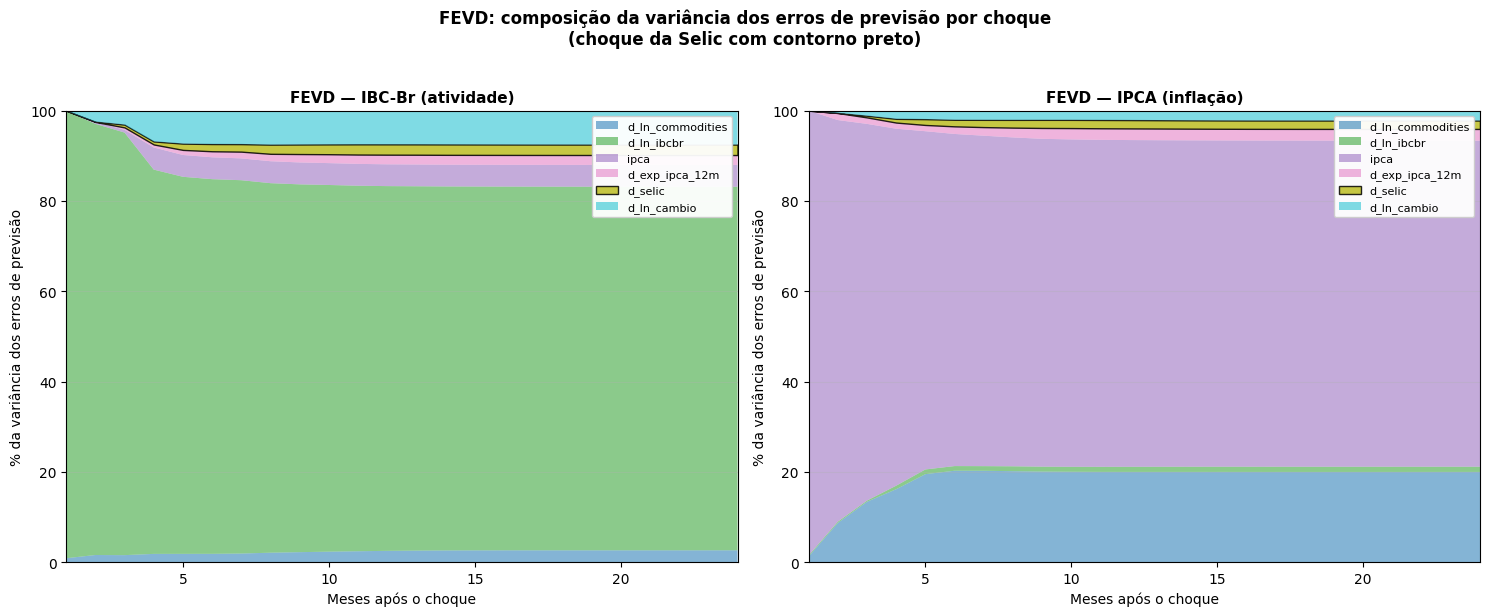

In [34]:
# =============================================================================
# Visualização: barras empilhadas
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cores = plt.cm.tab10(np.linspace(0, 1, K))
# Eixo x agora é 1-based, indo de h=1 a h=24
horizonte_x = np.arange(1, HORIZONTE_FEVD + 1)

for ax_idx, (i_resp, nome_resp) in enumerate(
    [(idx_ibcbr_resp, 'IBC-Br (atividade)'), 
     (idx_ipca_resp, 'IPCA (inflação)')]
):
    ax = axes[ax_idx]
    bottom = np.zeros(HORIZONTE_FEVD)
    
    for j_choque, nome_choque in enumerate(nomes_vars):
        contribuicao = fevd_array[i_resp, :, j_choque] * 100
        eh_selic = (nome_choque == 'd_selic')
        
        ax.fill_between(
            horizonte_x, bottom, bottom + contribuicao,
            color=cores[j_choque],
            alpha=0.85 if eh_selic else 0.55,
            label=nome_choque,
            edgecolor='black' if eh_selic else 'none',
            linewidth=1.0 if eh_selic else 0,
        )
        bottom += contribuicao
    
    ax.set_title(f'FEVD — {nome_resp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Meses após o choque')
    ax.set_ylabel('% da variância dos erros de previsão')
    ax.set_ylim(0, 100)
    ax.set_xlim(1, HORIZONTE_FEVD)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.95)

plt.suptitle(
    'FEVD: composição da variância dos erros de previsão por choque\n'
    '(choque da Selic com contorno preto)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/08_fevd_ibcbr_ipca.png',
            dpi=120, bbox_inches='tight')
plt.show()